# Notebook 03 — Эксперимент 1: Риск-профиль

## Исследовательский вопрос
**«Кем является акция в портфеле — защитником или агрессором?»**

## Метрики (после чистки корреляций)
| Метрика | Обоснование |
|---|---|
| sigma | Базовая мера риска, стандарт CAPM |
| beta | Системный риск относительно рынка |
| max_dd | Худший реализованный сценарий |
| cvar_95 | Хвостовой риск (Basel III), строже VaR |

> downside_dev исключён: ρ=0.991 с cvar_95

## Алгоритмы
| Алгоритм | Тип | Ключевая особенность |
|---|---|---|
| K-Means | Центроидный | Быстрый, жёсткое разбиение |
| Агломеративная (Ward) | Иерархический | Дендрограмма, не нужен K заранее |
| DBSCAN | Плотностной | Находит выбросы, не нужен K |
| **GMM** | **Вероятностный** | **Мягкое разбиение, вероятности принадлежности** |

## Три идеи добавлены
1. **Анализ стабильности** — кластеры на трёх подпериодах
2. **GMM** — вероятностная кластеризация
3. **Индекс неопределённости** — насколько алгоритмы согласны

## 1. Импорты и загрузка

In [1]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'font.size': 10,
})

df   = pd.read_parquet('data/features.parquet')
meta = pd.read_csv('data/sp500_meta.csv', index_col='ticker')
df   = df.join(meta[['sector', 'name']], how='left')

with open('data/feature_groups.json') as f:
    FEATURE_GROUPS = json.load(f)

FEATURES = FEATURE_GROUPS['risk']
LABELS   = {
    'sigma'  : 'Волатильность (σ)',
    'beta'   : 'Бета (β)',
    'max_dd' : 'Макс. просадка',
    
}
EXP_NAME    = 'Эксперимент 1: Риск-профиль'
SAVE_PREFIX = 'plots/03_exp1'

X_raw = df[FEATURES].dropna().copy()
print(f"Акций: {len(X_raw)} | Метрики: {FEATURES}")
X_raw.describe().round(3)

Акций: 481 | Метрики: ['sigma', 'beta', 'max_dd']


,sigma,beta,max_dd
count,481.000,481.000,481.000
mean,0.347,0.998,-0.505
std,0.099,0.297,0.140
min,0.193,0.269,-0.990
25%,0.281,0.797,-0.586
50%,0.323,0.994,-0.487
75%,0.388,1.177,-0.414
max,1.115,2.359,-0.226


Корреляционный анализ метрик риска

Матрица корреляции (Spearman):
        sigma   beta  max_dd
sigma   1.000  0.801  -0.826
beta    0.801  1.000  -0.599
max_dd -0.826 -0.599   1.000


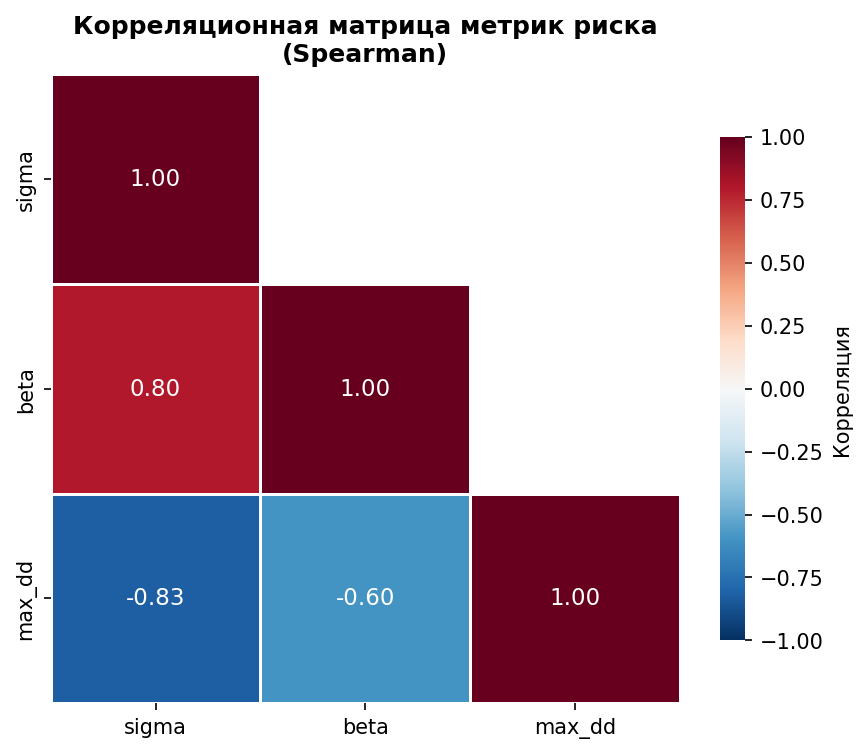


Пары метрик с высокой корреляцией (|ρ| > 0.7):
        Метрика 1      Метрика 2  Корреляция
Волатильность (σ)       Бета (β)       0.801
Волатильность (σ) Макс. просадка      -0.826

Визуализация сильно коррелирующих пар


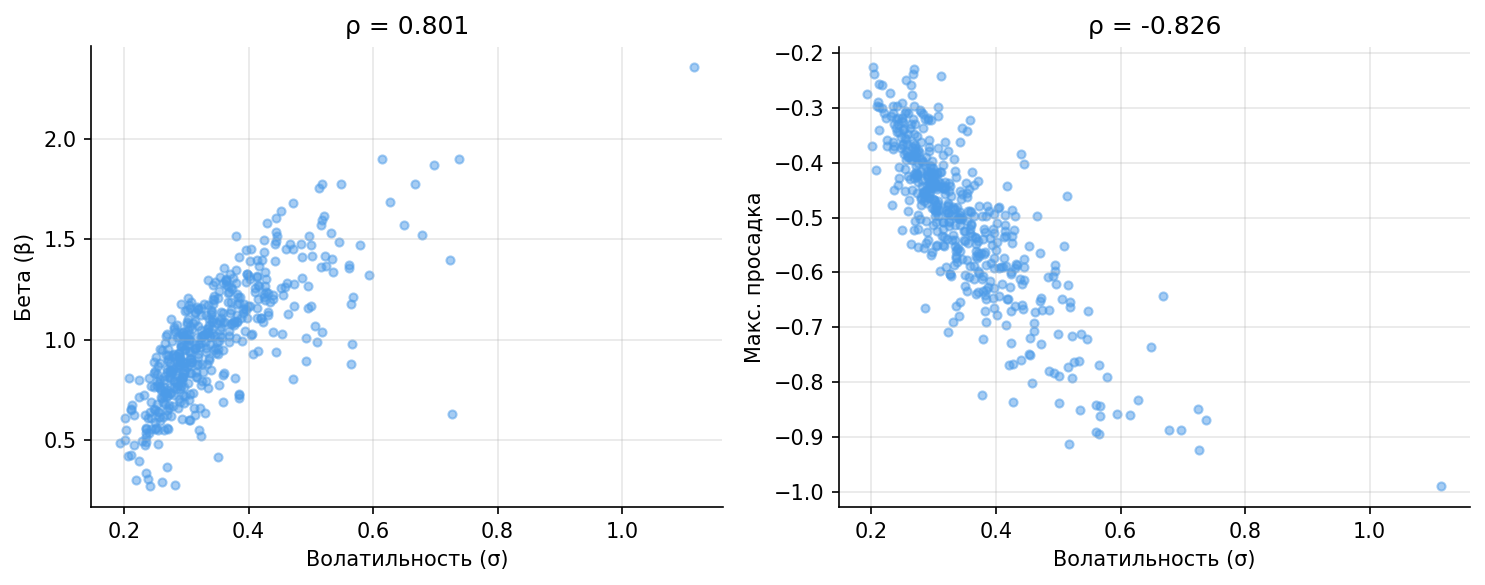

In [2]:
# ── КОРРЕЛЯЦИОННАЯ МАТРИЦА ДЛЯ МЕТРИК РИСКА ──────────────────────────────────────
print("=" * 60)
print("Корреляционный анализ метрик риска")
print("=" * 60)

# Рассчитываем корреляционную матрицу (Spearman — устойчива к выбросам)
corr_matrix = X_raw[FEATURES].corr(method='spearman')

print("\nМатрица корреляции (Spearman):")
print(corr_matrix.round(3).to_string())

# Визуализация: тепловая карта
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 11},
    cbar_kws={'shrink': 0.8, 'label': 'Корреляция'},
    ax=ax
)
ax.set_title(f'Корреляционная матрица метрик риска\n(Spearman)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Выявление сильно коррелирующих пар (|ρ| > 0.7)
print("\n" + "=" * 60)
print("Пары метрик с высокой корреляцией (|ρ| > 0.7):")
print("=" * 60)

high_corr = []
for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'Метрика 1': LABELS.get(FEATURES[i], FEATURES[i]),
                'Метрика 2': LABELS.get(FEATURES[j], FEATURES[j]),
                'Корреляция': round(r, 3)
            })

if high_corr:
    print(pd.DataFrame(high_corr).to_string(index=False))
else:
    print("  Сильно коррелирующих пар не обнаружено")

# Дополнительно: точечные графики для пар с высокой корреляцией
if high_corr:
    print("\n" + "=" * 60)
    print("Визуализация сильно коррелирующих пар")
    print("=" * 60)
    
    n_pairs = min(len(high_corr), 4)  # не более 4 графиков
    fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4))
    if n_pairs == 1:
        axes = [axes]
    
    for idx, pair in enumerate(high_corr[:n_pairs]):
        ax = axes[idx]
        feat1 = [k for k, v in LABELS.items() if v == pair['Метрика 1']][0]
        feat2 = [k for k, v in LABELS.items() if v == pair['Метрика 2']][0]
        
        ax.scatter(X_raw[feat1], X_raw[feat2], alpha=0.5, s=15, color='#4C9BE8')
        ax.set_xlabel(LABELS.get(feat1, feat1))
        ax.set_ylabel(LABELS.get(feat2, feat2))
        ax.set_title(f"ρ = {pair['Корреляция']:.3f}")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{SAVE_PREFIX}_correlation_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. Масштабирование

In [21]:
scaler   = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    index=X_raw.index, columns=FEATURES
)
print("После RobustScaler:")
X_scaled.describe().round(3)

После RobustScaler:


,sigma,beta,max_dd
count,481.000,481.000,481.000
mean,0.218,0.008,-0.103
std,0.916,0.781,0.812
min,-1.207,-1.910,-2.919
25%,-0.395,-0.520,-0.574
50%,0.000,0.000,0.000
75%,0.605,0.480,0.426
max,7.354,3.589,1.519


## 3. Выбор числа кластеров K

Четыре формальных критерия + дендрограмма.

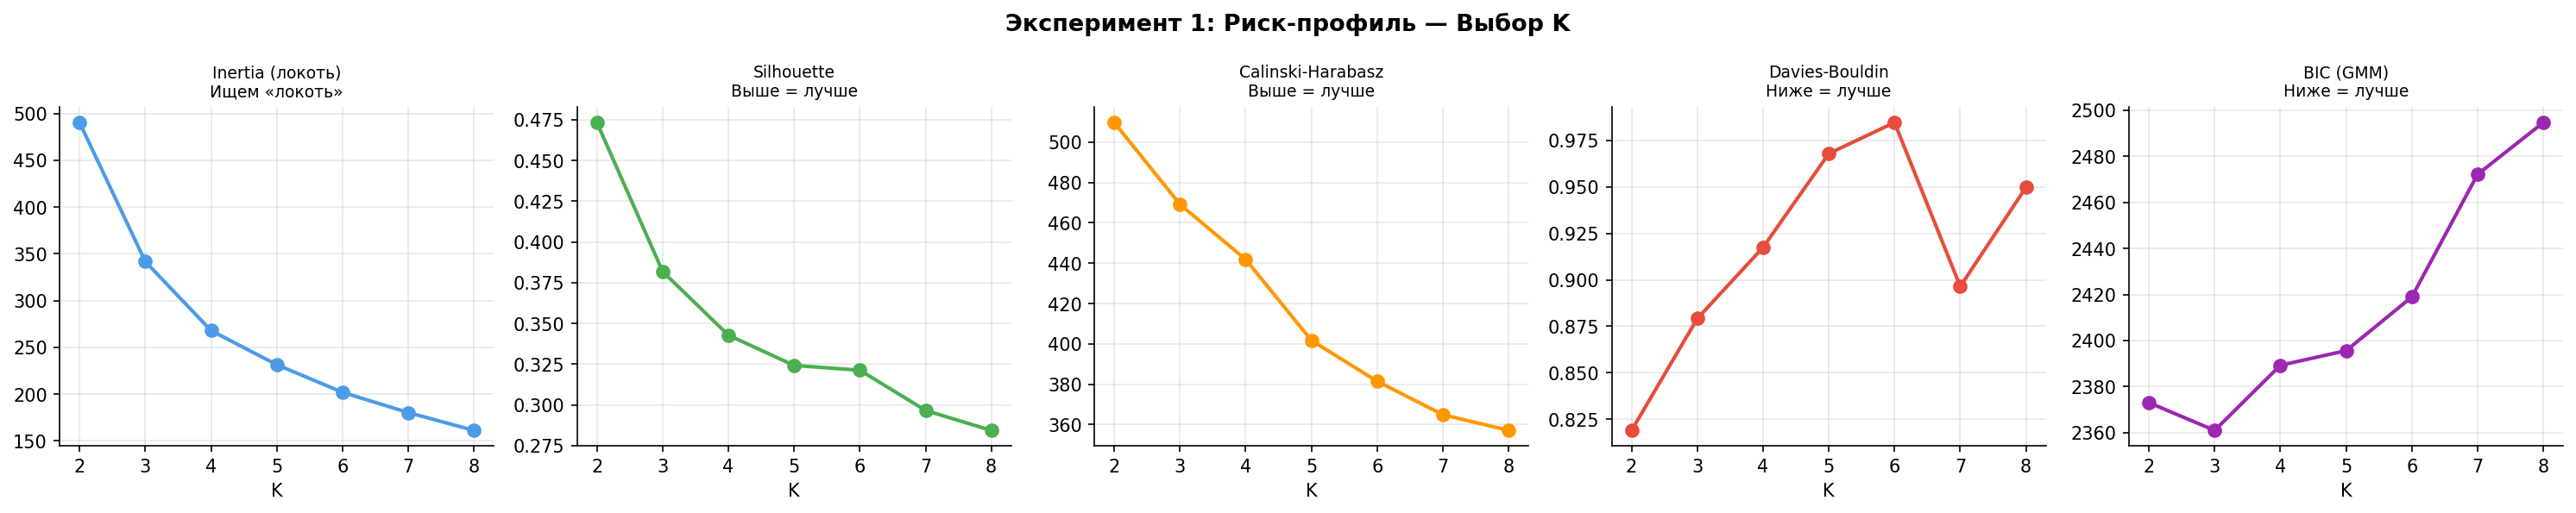

   Inertia  Silhouette     CH     DB  BIC(GMM)
K                                             
2    490.4       0.473  509.7  0.819    2373.0
3    341.6       0.382  469.1  0.879    2360.9
4    267.9       0.343  441.8  0.917    2389.2
5    231.3       0.324  401.7  0.968    2395.6
6    201.8       0.321  381.4  0.985    2418.9
7    180.2       0.297  364.9  0.896    2472.2
8    161.1       0.284  357.1  0.950    2494.7


In [22]:
K_RANGE = range(2, 9)
inertias, silhouettes, ch_scores, db_scores = [], [], [], []
bic_scores = []  # для GMM

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))

    gmm = GaussianMixture(n_components=k, random_state=42,
                          covariance_type='full', n_init=5)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'{EXP_NAME} — Выбор K', fontsize=13, fontweight='bold')

for ax, (vals, title, sub, color) in zip(axes, [
    (inertias,    'Inertia (локоть)',   'Ищем «локоть»',  '#4C9BE8'),
    (silhouettes, 'Silhouette',         'Выше = лучше',   '#4CAF50'),
    (ch_scores,   'Calinski-Harabasz',  'Выше = лучше',   '#FF9800'),
    (db_scores,   'Davies-Bouldin',     'Ниже = лучше',   '#e74c3c'),
    (bic_scores,  'BIC (GMM)',          'Ниже = лучше',   '#9C27B0'),
]):
    ax.plot(list(K_RANGE), vals, 'o-', color=color,
            linewidth=2, markersize=7)
    ax.set_title(f'{title}\n{sub}', fontsize=9)
    ax.set_xlabel('K')
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

k_table = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertia': [round(v,1) for v in inertias],
    'Silhouette': [round(v,3) for v in silhouettes],
    'CH': [round(v,1) for v in ch_scores],
    'DB': [round(v,3) for v in db_scores],
    'BIC(GMM)': [round(v,1) for v in bic_scores],
}).set_index('K')
print(k_table.to_string())

## 4. Дендрограмма

Эксперимент 1: Риск-профиль — Дендрограмма и метрики качества

Расстояния последних слияний:
  K=8→7: dist=5.482, gap=0.160
  K=7→6: dist=5.642, gap=1.825
  K=6→5: dist=7.467, gap=0.473
  K=5→4: dist=7.940, gap=0.566
  K=4→3: dist=8.506, gap=5.778
  K=3→2: dist=14.283, gap=0.265
  K=2→1: dist=14.549, gap=17.583 ← МАКСИМУМ

→ Дендрограмма предлагает K=2

Метрики качества для разных K (агломеративная кластеризация)

   Silhouette     CH     DB
K                          
2       0.467  498.4  0.824
3       0.329  381.0  0.899
4       0.338  399.4  0.895
5       0.298  358.9  1.085
6       0.280  341.0  1.172
7       0.282  336.1  1.038
8       0.288  319.4  0.971

(Оптимальное K: Silhouette↑, CH↑, DB↓)

Профили кластеров для каждого K

──────────────────────────────────────────────────
K = 2
──────────────────────────────────────────────────
 Кластер  Акций     σ     β  Max DD
       0    324 0.295 0.860  -0.437
       1    157 0.454 1.282  -0.646

───────────────────────────────────────

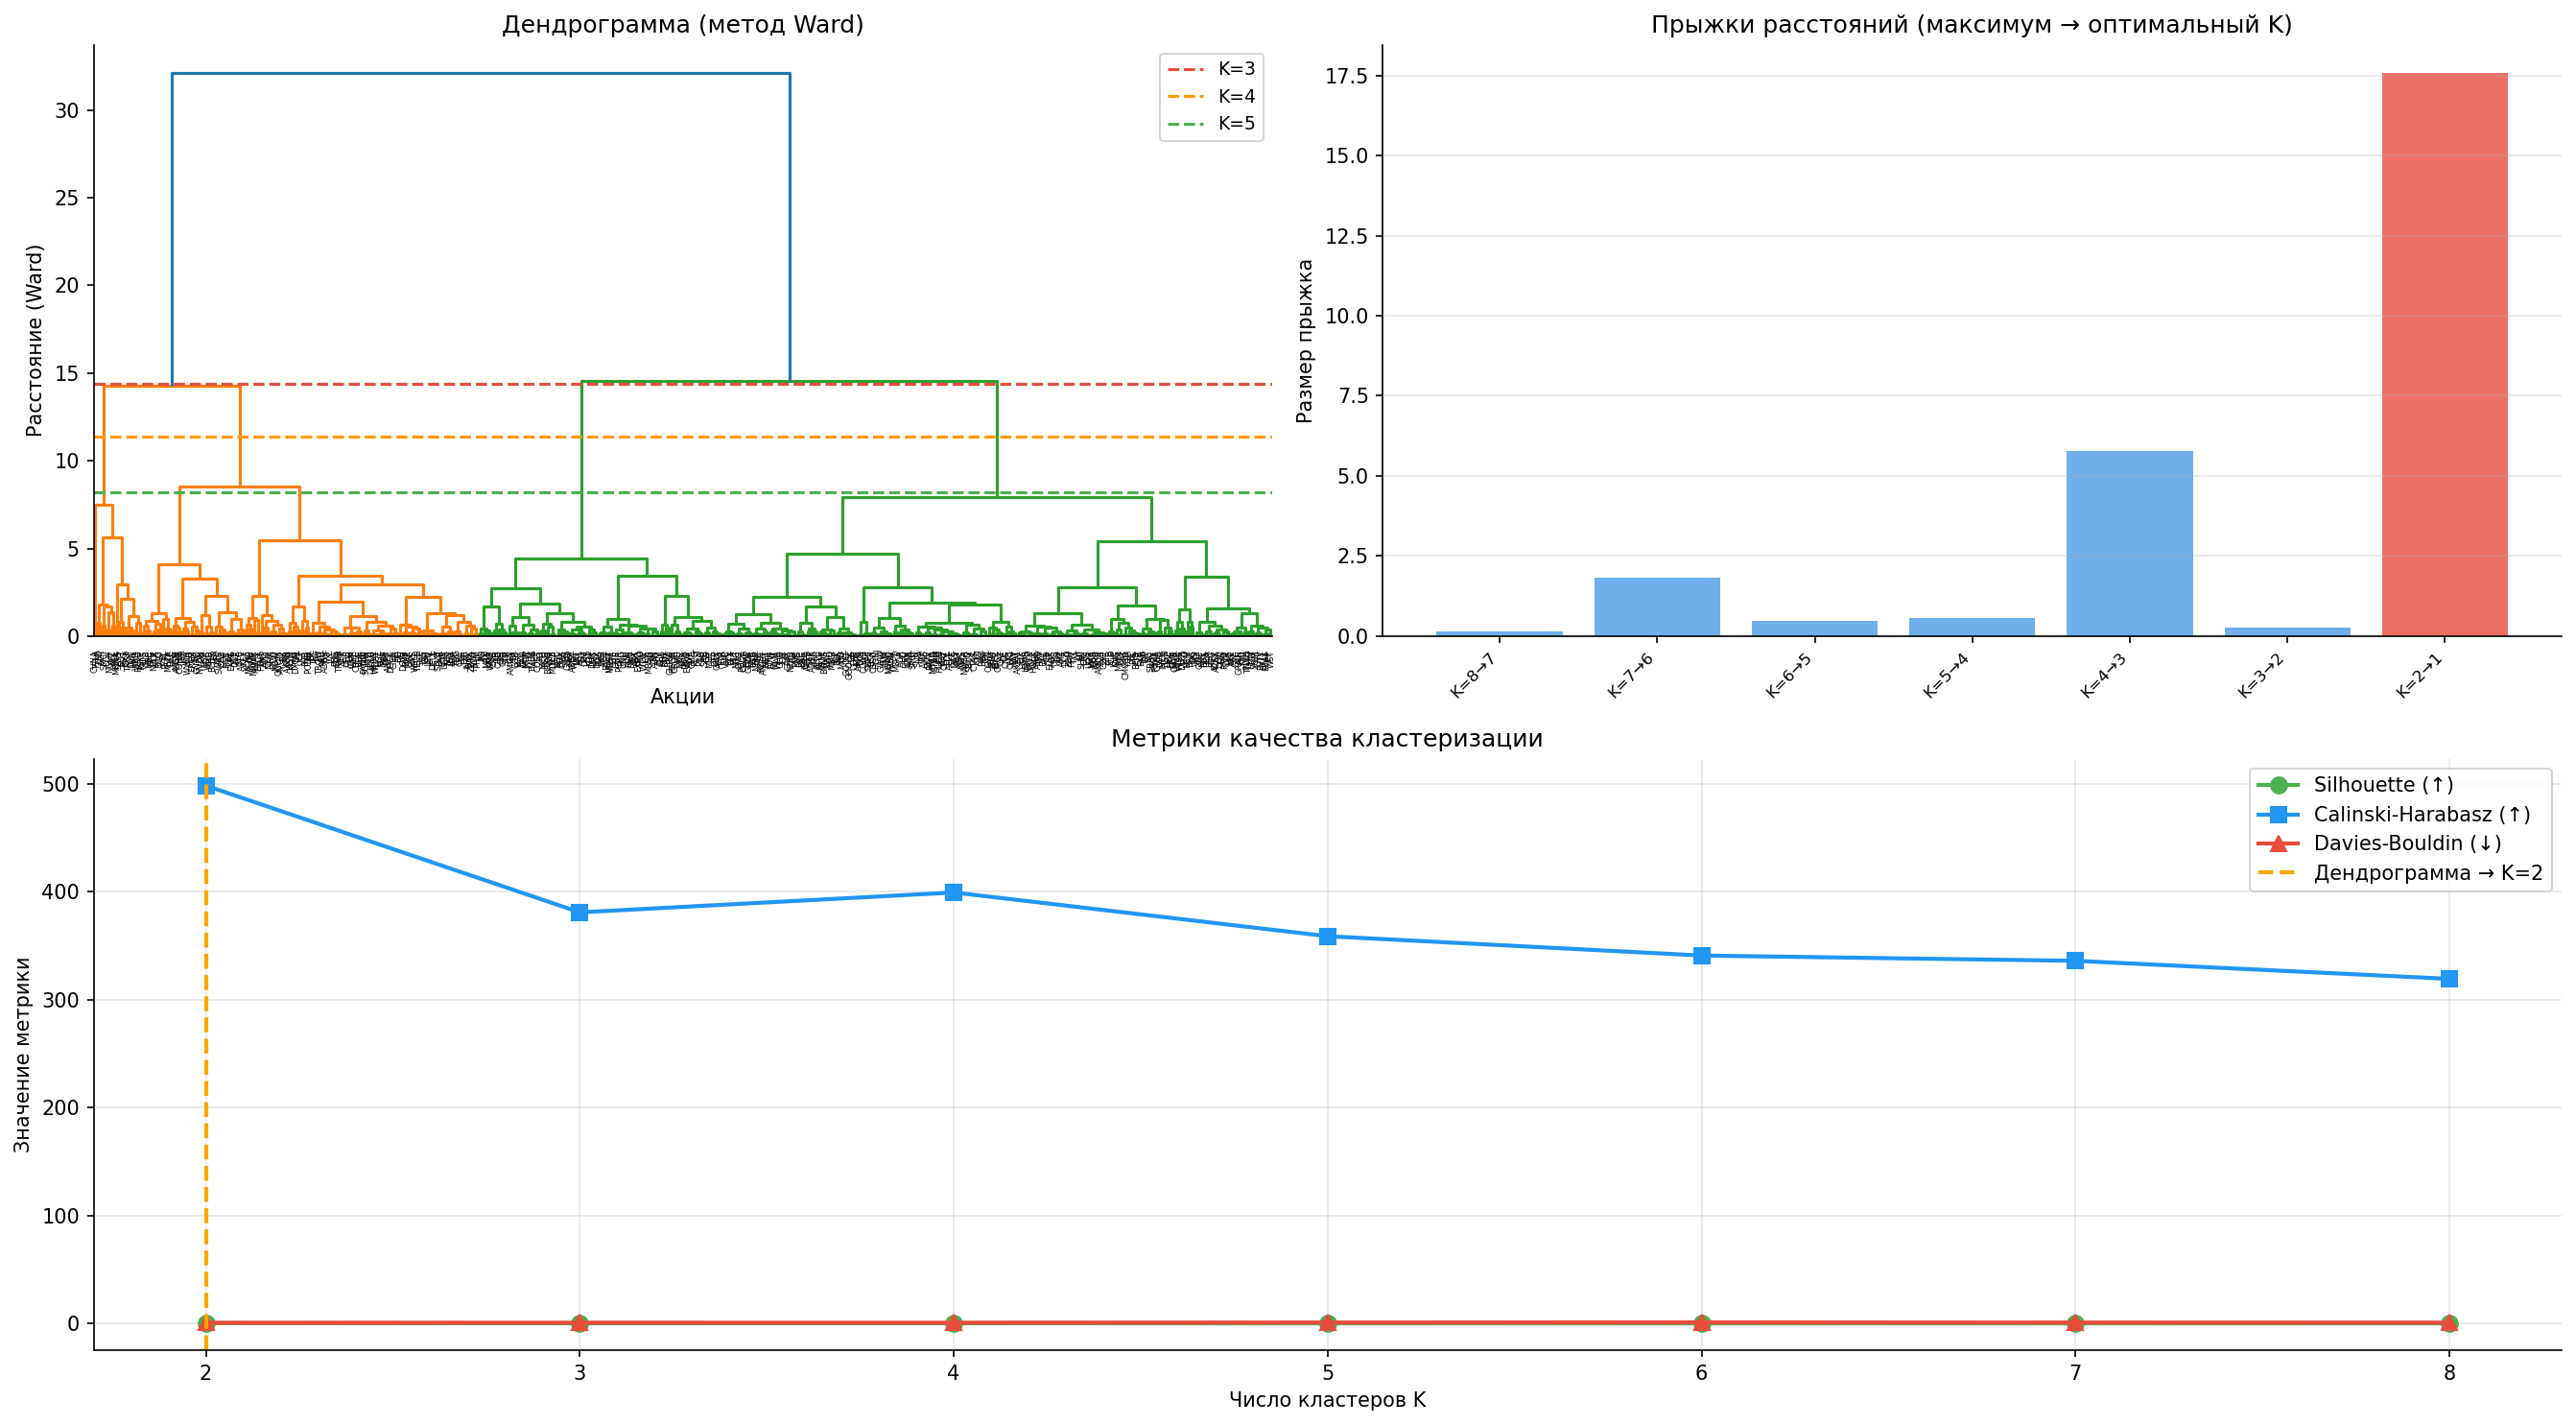

In [23]:
# ── ДЕНДРОГРАММА И МЕТРИКИ КАЧЕСТВА ДЛЯ K=2..8 ──────────────────────────────────
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Строим матрицу связей
Z = linkage(X_scaled, method='ward')

# ── 1. АНАЛИЗ ПРЫЖКОВ (оставляем как есть) ─────────────────────────────────────
N_LAST = 8
last_dists = Z[-N_LAST:, 2]
gaps = np.diff(last_dists)
dendro_k = N_LAST - int(np.argmax(gaps))

print("=" * 70)
print(f"{EXP_NAME} — Дендрограмма и метрики качества")
print("=" * 70)

print("\nРасстояния последних слияний:")
for i in range(len(gaps)):
    m = " ← МАКСИМУМ" if gaps[i] == gaps.max() else ""
    print(f"  K={N_LAST-i}→{N_LAST-i-1}: dist={last_dists[i]:.3f}, gap={gaps[i]:.3f}{m}")
print(f"\n→ Дендрограмма предлагает K={dendro_k}")

# ── 2. РАСЧЁТ МЕТРИК ДЛЯ K=2..8 ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Метрики качества для разных K (агломеративная кластеризация)")
print("=" * 70)

K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': []}

for k in K_RANGE:
    # Получаем метки кластеров из дендрограммы
    labels = cut_tree(Z, n_clusters=k).flatten()
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))

# Выводим таблицу
results_df = pd.DataFrame(results).set_index('K')
print("\n" + results_df.to_string())
print("\n(Оптимальное K: Silhouette↑, CH↑, DB↓)")

# ── 3. ВЫВОД ПРОФИЛЕЙ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ──────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K")
print("=" * 70)

for k in K_RANGE:
    labels = cut_tree(Z, n_clusters=k).flatten()
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    # Собираем данные по кластерам
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        sigma_mean = X_raw.loc[mask, 'sigma'].mean()
        beta_mean = X_raw.loc[mask, 'beta'].mean()
        max_dd_mean = X_raw.loc[mask, 'max_dd'].mean()
        
        profile_data.append({
            'Кластер': cluster_id,
            'Акций': n_stocks,
            'σ': round(sigma_mean, 3),
            'β': round(beta_mean, 3),
            'Max DD': round(max_dd_mean, 3)
        })
    
    profile_df = pd.DataFrame(profile_data)
    print(profile_df.to_string(index=False))

# ── 4. ВИЗУАЛИЗАЦИЯ (дендрограмма + график метрик) ─────────────────────────────
fig = plt.figure(figsize=(18, 10))

# Дендрограмма (левая часть)
ax1 = plt.subplot(2, 2, 1)
dendrogram(Z, labels=X_scaled.index.tolist(),
           leaf_rotation=90, leaf_font_size=4,
           color_threshold=0.7*max(Z[:,2]), ax=ax1)
ax1.set_xlabel('Акции')
ax1.set_ylabel('Расстояние (Ward)')
for k_cut, color in {3:'#e74c3c',4:'#FF9800',5:'#4CAF50'}.items():
    idx = -(k_cut-1)
    thr = (Z[idx-1,2]+Z[idx,2])/2
    ax1.axhline(thr, linestyle='--', linewidth=1.5, color=color, label=f'K={k_cut}')
ax1.legend(fontsize=9)
ax1.set_title('Дендрограмма (метод Ward)')

# График прыжков (правая верхняя)
ax2 = plt.subplot(2, 2, 2)
k_vals = list(range(N_LAST, N_LAST-len(gaps), -1))
ax2.bar(range(len(gaps)), gaps,
        color=['#e74c3c' if g==gaps.max() else '#4C9BE8' for g in gaps], alpha=0.8)
ax2.set_xticks(range(len(gaps)))
ax2.set_xticklabels([f'K={k}→{k-1}' for k in k_vals], rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Размер прыжка')
ax2.set_title('Прыжки расстояний (максимум → оптимальный K)')
ax2.grid(axis='y', alpha=0.3)

# График метрик качества (нижняя часть)
ax3 = plt.subplot(2, 1, 2)

# Нормализуем метрики для отображения на одном графике
sil_norm = (results_df['Silhouette'] - results_df['Silhouette'].min()) / (results_df['Silhouette'].max() - results_df['Silhouette'].min())
ch_norm = (results_df['CH'] - results_df['CH'].min()) / (results_df['CH'].max() - results_df['CH'].min())
db_norm = 1 - (results_df['DB'] - results_df['DB'].min()) / (results_df['DB'].max() - results_df['DB'].min())  # инвертируем

ax3.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax3.plot(results_df.index, results_df['CH'], 's-', color='#2196F3', linewidth=2, markersize=8, label='Calinski-Harabasz (↑)')
ax3.plot(results_df.index, results_df['DB'], '^-', color='#e74c3c', linewidth=2, markersize=8, label='Davies-Bouldin (↓)')
ax3.axvline(dendro_k, color='orange', linestyle='--', linewidth=2, label=f'Дендрограмма → K={dendro_k}')
ax3.set_xlabel('Число кластеров K')
ax3.set_ylabel('Значение метрики')
ax3.set_title('Метрики качества кластеризации')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_dendrogram_with_metrics.png', dpi=150, bbox_inches='tight')
plt.show()



## 5. Качественный анализ профилей K=2,3,4,5

Главный критерий — интерпретируемость.


=======================================================  K=2


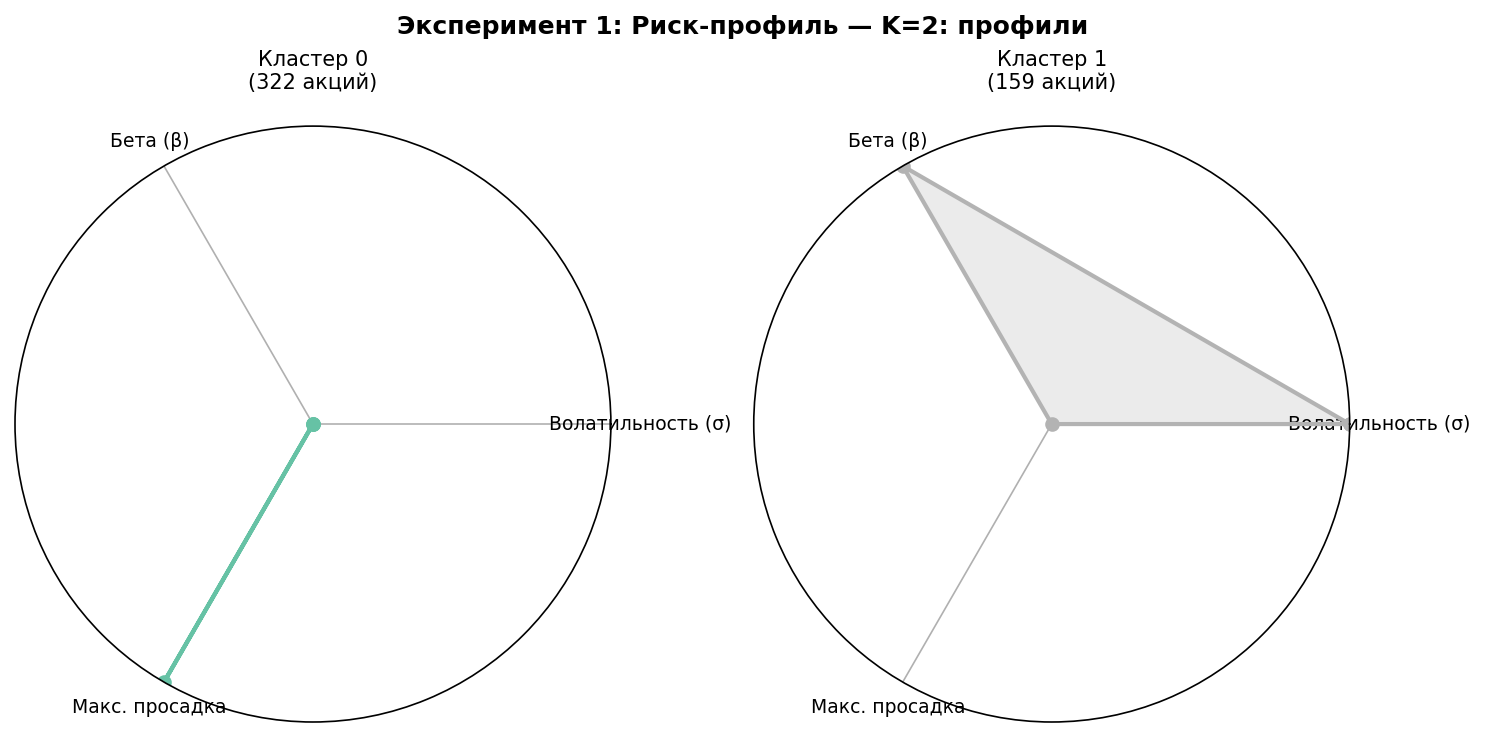


Средние значения (K=2):
           Волатильность (σ)  Бета (β)  Макс. просадка  Акций
Кластер 0              0.294     0.857          -0.436    322
Кластер 1              0.453     1.283          -0.646    159

=======================================================  K=3


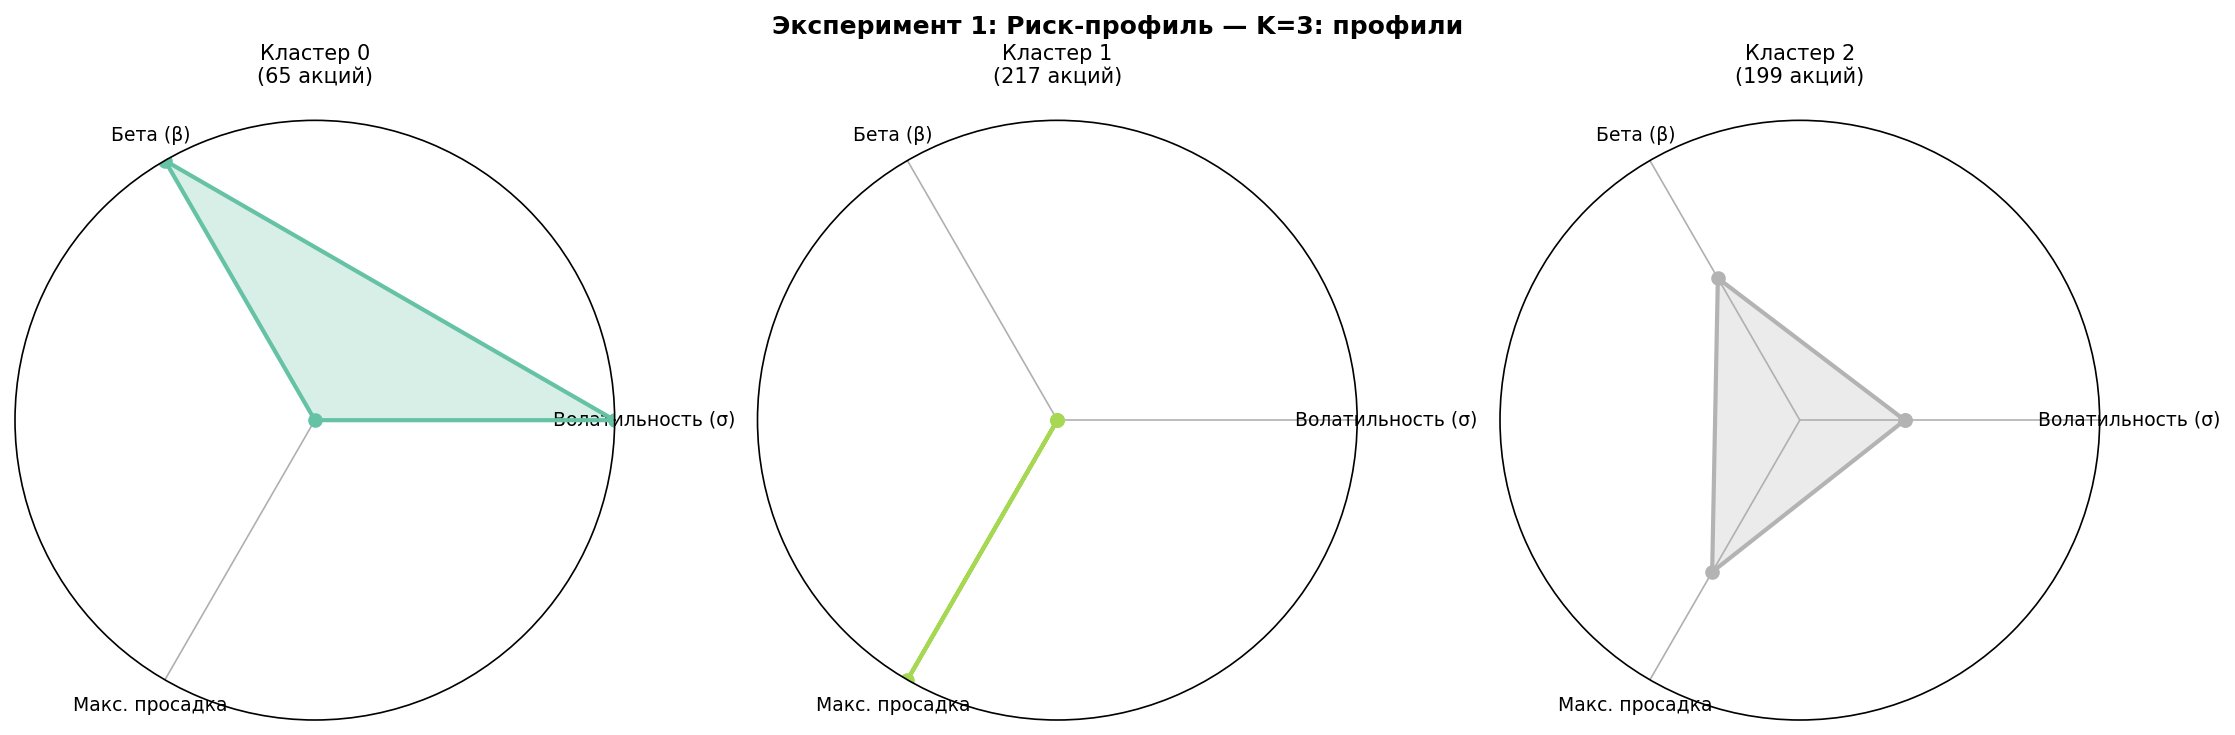


Средние значения (K=3):
           Волатильность (σ)  Бета (β)  Макс. просадка  Акций
Кластер 0              0.531     1.398          -0.741     65
Кластер 1              0.275     0.771          -0.401    217
Кластер 2              0.365     1.114          -0.542    199

=======================================================  K=4


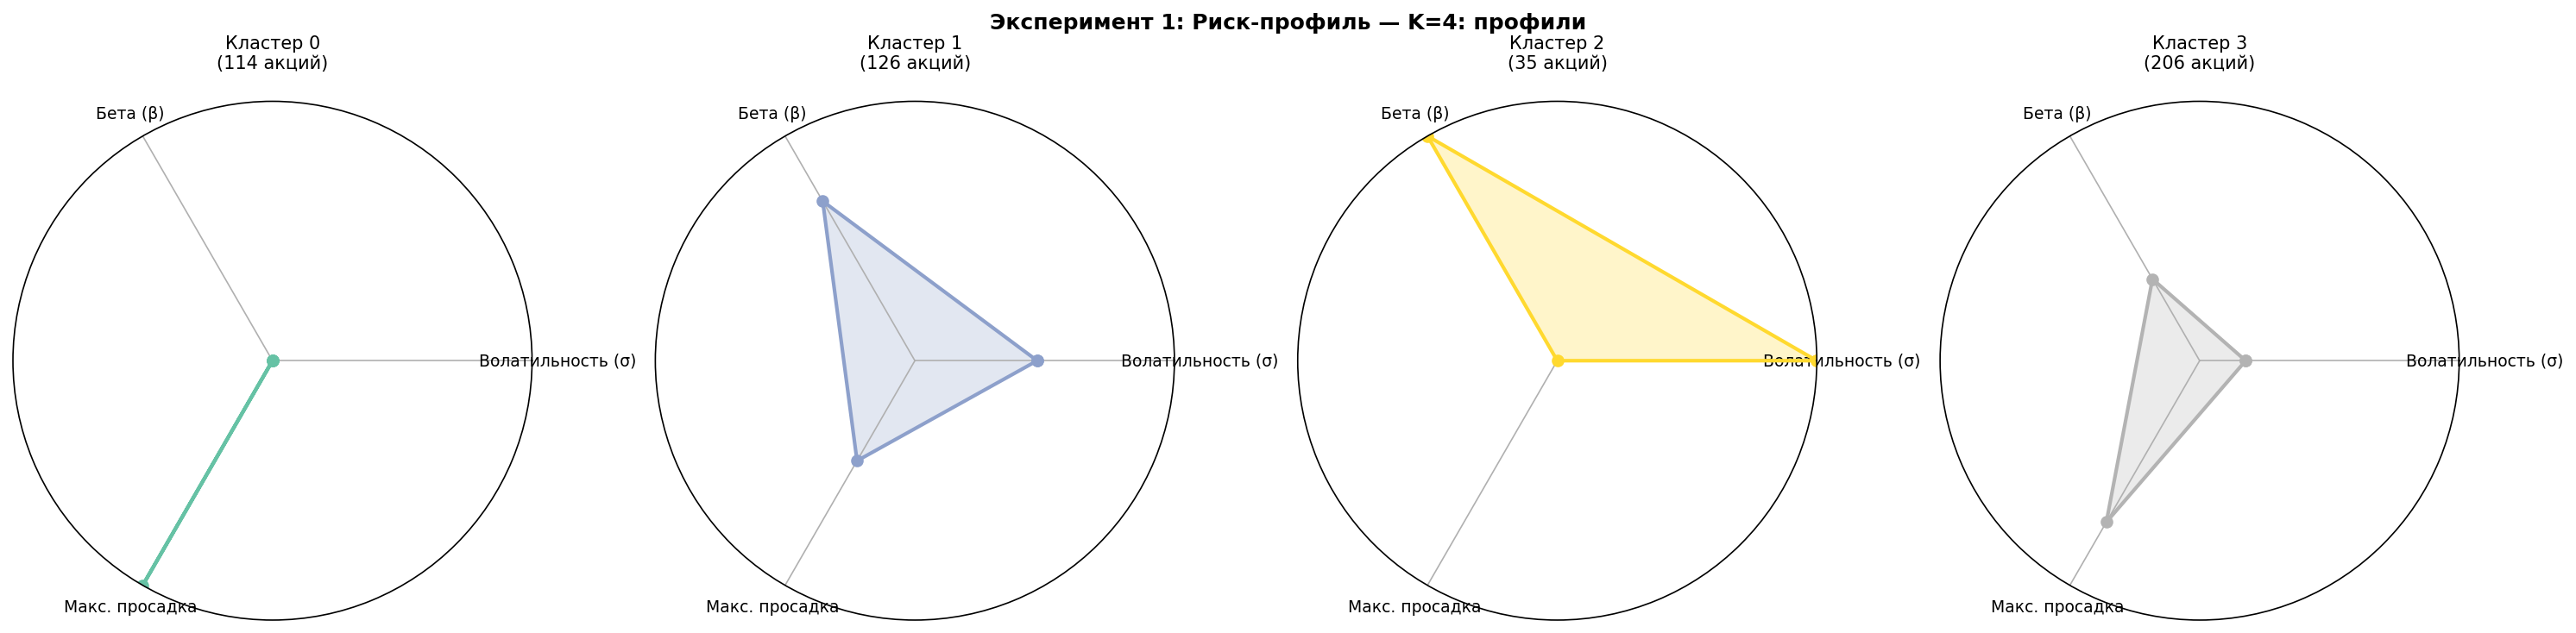


Средние значения (K=4):
           Волатильность (σ)  Бета (β)  Макс. просадка  Акций
Кластер 0              0.256     0.669          -0.355    114
Кластер 1              0.413     1.232          -0.601    126
Кластер 2              0.590     1.461          -0.799     35
Кластер 3              0.315     0.957          -0.480    206

=======================================================  K=5


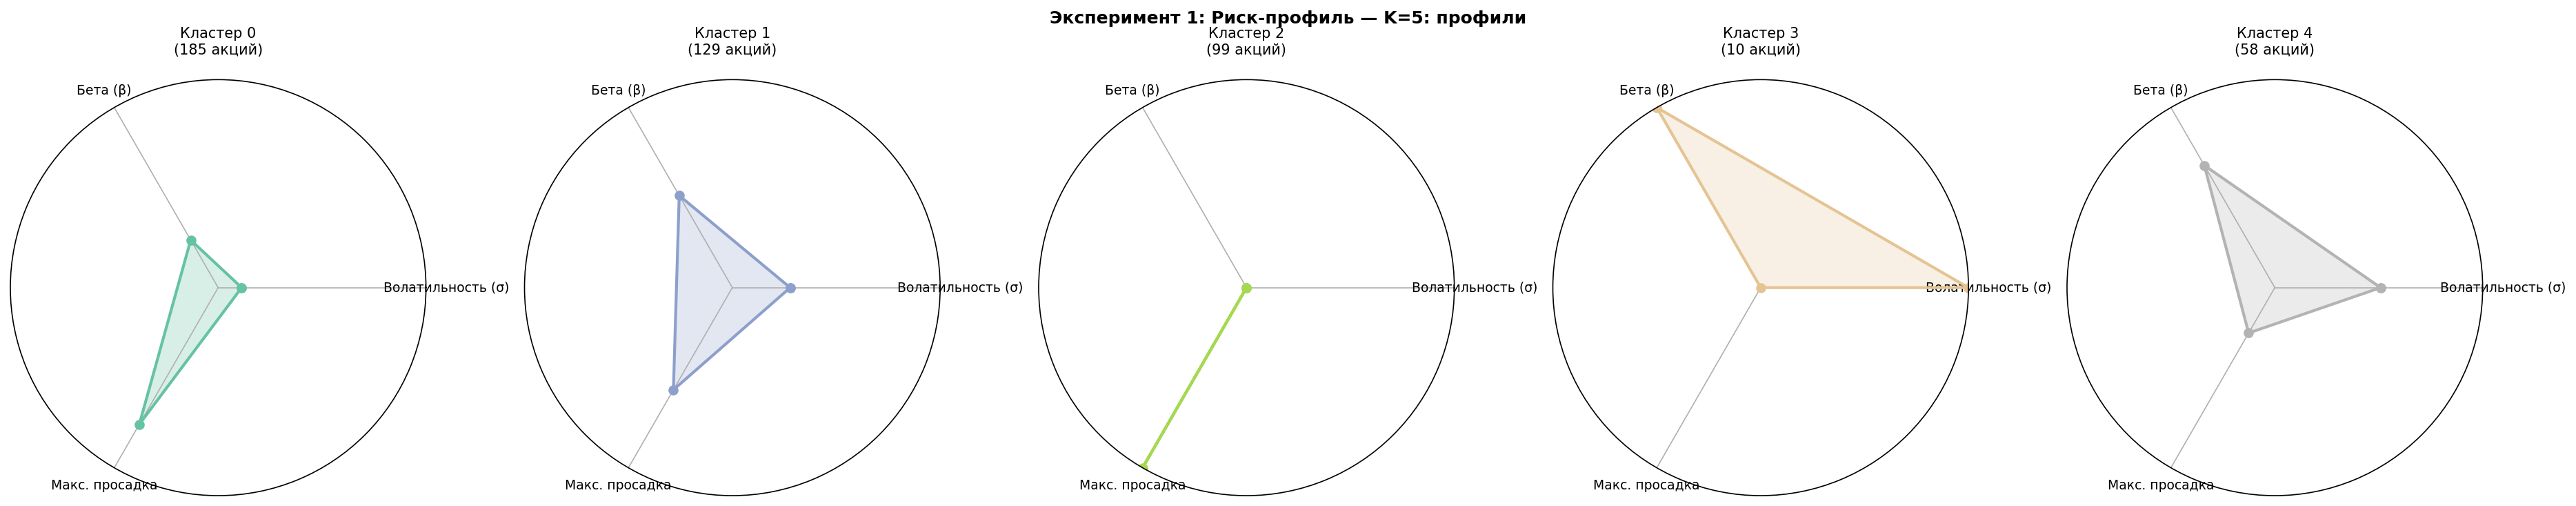


Средние значения (K=5):
           Волатильность (σ)  Бета (β)  Макс. просадка  Акций
Кластер 0              0.306     0.920          -0.465    185
Кластер 1              0.383     1.169          -0.562    129
Кластер 2              0.252     0.653          -0.344     99
Кластер 3              0.724     1.662          -0.848     10
Кластер 4              0.492     1.338          -0.721     58


In [24]:
def plot_profiles(X_raw, labels, feature_labels, title, k,
                  save_path=None):
    feats    = list(feature_labels.keys())
    f_lbls   = list(feature_labels.values())
    n_cl     = len(np.unique(labels))
    colors   = plt.cm.Set2(np.linspace(0, 1, n_cl))
    tmp      = X_raw[feats].copy()
    tmp['c'] = labels
    prof_raw = tmp.groupby('c')[feats].mean()
    prof_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(prof_raw),
        columns=feats, index=prof_raw.index
    )
    angles = np.linspace(0, 2*np.pi, len(feats),
                          endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(5*n_cl, 5))
    fig.suptitle(f'{title} — K={k}: профили',
                 fontsize=12, fontweight='bold')
    for i in range(n_cl):
        ax   = fig.add_subplot(1, n_cl, i+1, polar=True)
        vals = prof_norm.iloc[i].tolist() + [prof_norm.iloc[i].iloc[0]]
        ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i])
        ax.fill(angles, vals, alpha=0.25, color=colors[i])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(f_lbls, size=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_title(f'Кластер {i}\n({(labels==i).sum()} акций)',
                     size=10, pad=18)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    out          = prof_raw.copy()
    out.columns  = [feature_labels[c] for c in feats]
    out.index    = [f'Кластер {i}' for i in out.index]
    out['Акций'] = [(labels==i).sum() for i in prof_raw.index]
    print(f"\nСредние значения (K={k}):")
    print(out.round(3).to_string())
    return prof_raw


all_km_labels = {}
for k in [2,3, 4, 5]:
    print(f"\n{'='*55}  K={k}")
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    all_km_labels[k] = lbl
    plot_profiles(X_raw, lbl, LABELS, EXP_NAME, k,
                  f'{SAVE_PREFIX}_profiles_k{k}.png')

## 6. Финальный выбор K

**Обнови K_FINAL и CLUSTER_NAMES после просмотра профилей.**

In [25]:
K_FINAL = 4  # ← обнови

CLUSTER_NAMES = {
    0: ('Защитные',       '#2196F3'),  # β≈0.95, среднерыночные
    1: ('Умеренно-агрессивные',    '#e74c3c'),  # β=1.46, экстремальные
    2: ('Агрессивные',       '#4CAF50'),  # β=0.67, ниже рынка
    3: ('Рыночные', '#FF9800'),  # β=1.22
}
# ВАЖНО: обнови названия под реальные профили!

km_final   = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
labels_km  = km_final.fit_predict(X_scaled)

agg_final  = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_agg = agg_final.fit_predict(X_scaled)

X_result = X_raw.copy()
X_result['cluster_km']   = labels_km
X_result['cluster_agg']  = labels_agg
X_result['cluster_name'] = [CLUSTER_NAMES[c][0] for c in labels_km]
X_result['sector']       = df.loc[X_raw.index, 'sector']
X_result['name']         = df.loc[X_raw.index, 'name']

print(f"K={K_FINAL}")
for c, (name, _) in CLUSTER_NAMES.items():
    print(f"  {c}: {name} — {(labels_km==c).sum()} акций")

K=4
  0: Защитные — 114 акций
  1: Умеренно-агрессивные — 126 акций
  2: Агрессивные — 35 акций
  3: Рыночные — 206 акций


## 7. GMM — вероятностная кластеризация

GMM в отличие от K-Means даёт **вероятность** принадлежности
к каждому кластеру. Акция на границе получит, например,
P(Рыночные)=0.6, P(Умеренно-агрессивные)=0.4.
Это честнее отражает реальность — нет чёткой границы.

Эксперимент 1: Риск-профиль — GMM анализ для K=2..8

  GMM K=2... Sil=0.436, CH=332.2, DB=0.943, BIC=2373

  GMM K=3... Sil=0.304, CH=258.9, DB=1.249, BIC=2361

  GMM K=4... Sil=0.222, CH=238.8, DB=1.106, BIC=2389

  GMM K=5... Sil=0.204, CH=201.1, DB=1.003, BIC=2396

  GMM K=6... Sil=0.142, CH=185.6, DB=1.127, BIC=2419

  GMM K=7... Sil=0.096, CH=165.0, DB=1.229, BIC=2472

  GMM K=8... Sil=0.192, CH=235.3, DB=1.166, BIC=2495

Таблица 1. Метрики качества GMM для K=2..8
   Silhouette     CH     DB     BIC     AIC
K                                          
2       0.436  332.2  0.943  2373.0  2293.7
3       0.304  258.9  1.249  2360.9  2239.8
4       0.222  238.8  1.106  2389.2  2226.4
5       0.204  201.1  1.003  2395.6  2191.0
6       0.142  185.6  1.127  2418.9  2172.5
7       0.096  165.0  1.229  2472.2  2184.0
8       0.192  235.3  1.166  2494.7  2164.8

📈 Оптимальные K по разным критериям (GMM):
  • Silhouette (макс):      K = 2  (значение = 0.436)
  • Calinski-Harabasz (макс): K 

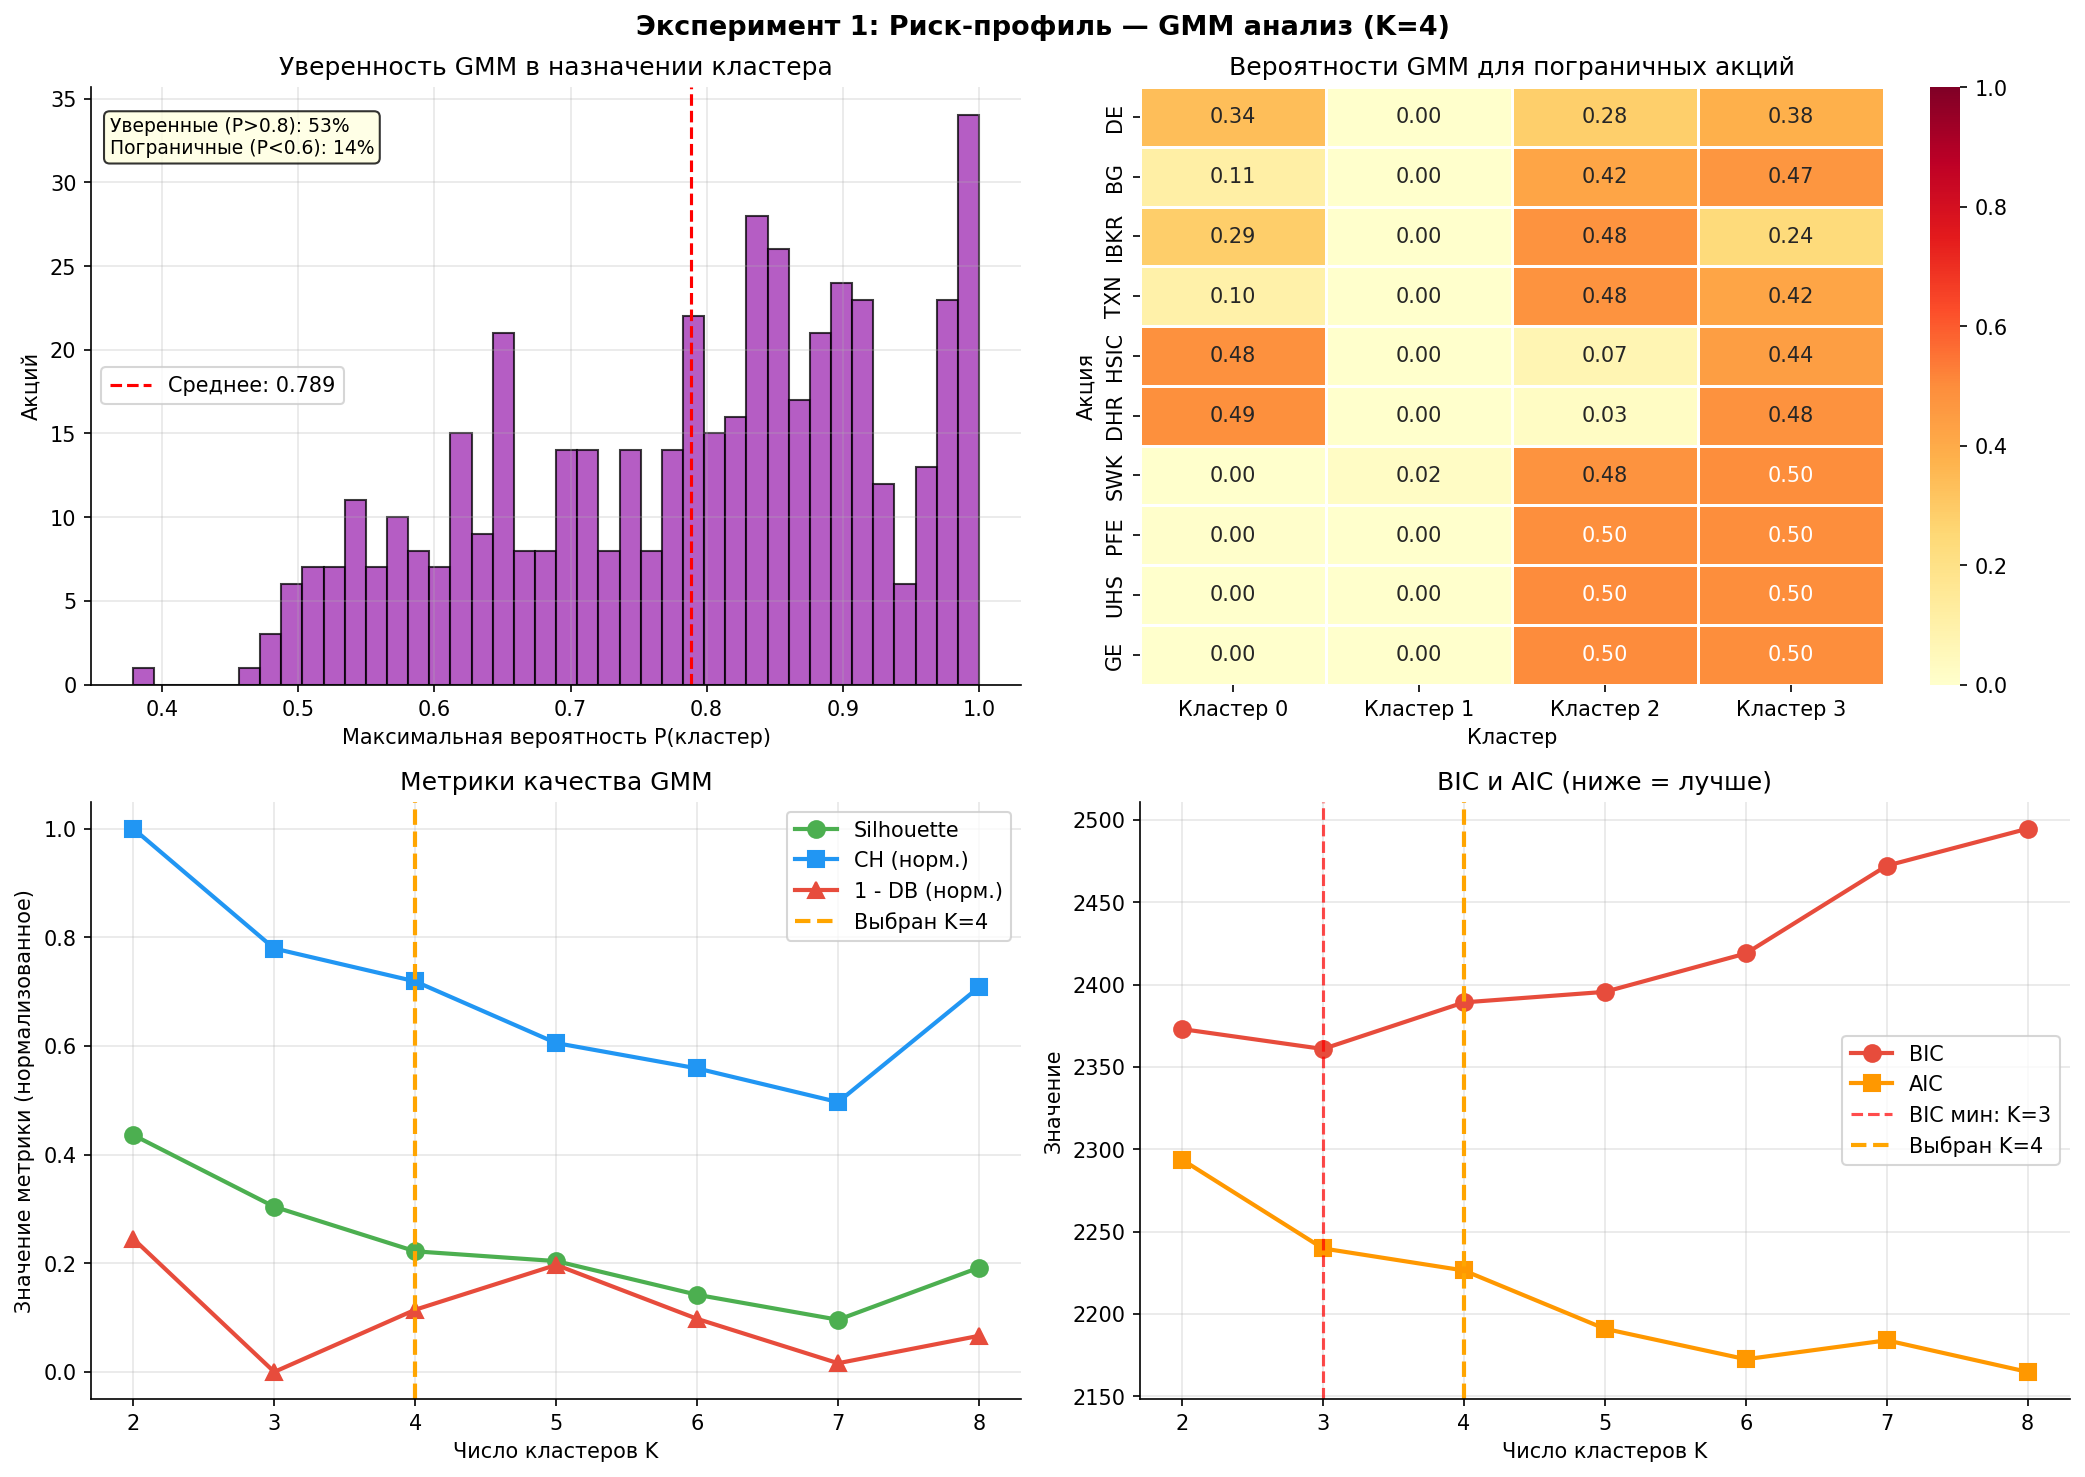

In [26]:
# ── GMM (Gaussian Mixture Model) с полным анализом для K=2..8 ──────────────────
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — GMM анализ для K=2..8")
print("=" * 70)

K_RANGE = range(2, 9)

# Хранилища результатов
results_gmm = {
    'K': [],
    'Silhouette': [],
    'CH': [],
    'DB': [],
    'BIC': [],
    'AIC': []
}

# Храним модели и метки для каждого K
gmm_models = {}
gmm_labels_all = {}
gmm_proba_all = {}

for k in K_RANGE:
    print(f"\n  GMM K={k}...", end=' ', flush=True)
    
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10,
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    proba = gmm.predict_proba(X_scaled)
    
    gmm_models[k] = gmm
    gmm_labels_all[k] = labels
    gmm_proba_all[k] = proba
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    
    results_gmm['K'].append(k)
    results_gmm['Silhouette'].append(round(sil, 3))
    results_gmm['CH'].append(round(ch, 1))
    results_gmm['DB'].append(round(db, 3))
    results_gmm['BIC'].append(round(bic, 1))
    results_gmm['AIC'].append(round(aic, 1))
    
    print(f"Sil={sil:.3f}, CH={ch:.1f}, DB={db:.3f}, BIC={bic:.0f}")

# ── ТАБЛИЦА 1: Метрики GMM для всех K ─────────────────────────────────────────
print("\n" + "=" * 70)
print("Таблица 1. Метрики качества GMM для K=2..8")
print("=" * 70)
df_gmm = pd.DataFrame(results_gmm).set_index('K')
print(df_gmm.to_string())

# Оптимальные K по разным критериям
best_gmm_sil = df_gmm['Silhouette'].idxmax()
best_gmm_ch = df_gmm['CH'].idxmax()
best_gmm_db = df_gmm['DB'].idxmin()
best_gmm_bic = df_gmm['BIC'].idxmin()
best_gmm_aic = df_gmm['AIC'].idxmin()

print("\n📈 Оптимальные K по разным критериям (GMM):")
print(f"  • Silhouette (макс):      K = {best_gmm_sil}  (значение = {df_gmm.loc[best_gmm_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс): K = {best_gmm_ch}  (значение = {df_gmm.loc[best_gmm_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):   K = {best_gmm_db}  (значение = {df_gmm.loc[best_gmm_db, 'DB']:.3f})")
print(f"  • BIC (мин):              K = {best_gmm_bic}  (значение = {df_gmm.loc[best_gmm_bic, 'BIC']:.0f})")
print(f"  • AIC (мин):              K = {best_gmm_aic}  (значение = {df_gmm.loc[best_gmm_aic, 'AIC']:.0f})")

# ── ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ───────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (GMM)")
print("=" * 70)

for k in K_RANGE:
    labels = gmm_labels_all[k]
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        sigma_mean = X_raw.loc[mask, 'sigma'].mean()
        beta_mean = X_raw.loc[mask, 'beta'].mean()
        max_dd_mean = X_raw.loc[mask, 'max_dd'].mean()
        
        # Средняя уверенность GMM в этом кластере
        proba = gmm_proba_all[k][mask]
        max_proba_mean = proba.max(axis=1).mean()
        
        profile_data.append({
            'Кластер': cluster_id,
            'Акций': n_stocks,
            'σ': round(sigma_mean, 3),
            'β': round(beta_mean, 3),
            'Max DD': round(max_dd_mean, 3),
            'Уверенность': round(max_proba_mean, 3)
        })
    
    profile_df = pd.DataFrame(profile_data)
    print(profile_df.to_string(index=False))

# ── ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ K_FINAL (финальный выбор) ────────────────────────────
print("\n" + "=" * 70)
print(f"ДЕТАЛЬНЫЙ АНАЛИЗ GMM ДЛЯ K = {K_FINAL}")
print("=" * 70)

# Берём финальную модель
gmm_final = gmm_models[K_FINAL]
labels_gmm = gmm_labels_all[K_FINAL]
proba_gmm = gmm_proba_all[K_FINAL]

max_proba = proba_gmm.max(axis=1)
uncertainty = 1 - max_proba

# Сохраняем в X_result
X_result['cluster_gmm'] = labels_gmm
X_result['gmm_max_prob'] = max_proba
X_result['gmm_uncertainty'] = uncertainty

print(f"\nGMM (K={K_FINAL}):")
for c in range(K_FINAL):
    mask = labels_gmm == c
    if mask.sum() > 0:
        print(f"  Кластер {c}: {mask.sum()} акций, средняя уверенность {max_proba[mask].mean():.3f}")

# Распределение уверенности
print(f"\nРаспределение уверенности GMM:")
print(f"  • P > 0.9 (уверенные):     {(max_proba > 0.9).sum()} акций ({(max_proba > 0.9).mean()*100:.0f}%)")
print(f"  • P > 0.8:                 {(max_proba > 0.8).sum()} акций ({(max_proba > 0.8).mean()*100:.0f}%)")
print(f"  • P < 0.6 (пограничные):   {(max_proba < 0.6).sum()} акций ({(max_proba < 0.6).mean()*100:.0f}%)")
print(f"  • Средняя уверенность:     {max_proba.mean():.3f}")

# Пограничные акции (с наименьшей уверенностью)
print(f"\n📌 Топ-15 акций с наибольшей неопределённостью (пограничные):")
uncertain_df = pd.DataFrame({
    'Акция': X_raw.index,
    'Кластер GMM': labels_gmm,
    'Max P(GMM)': max_proba.round(3),
    'Неопределённость': uncertainty.round(3),
})
# Добавляем названия кластеров из KM для сравнения
if 'cluster_exp1_name' in X_result.columns:
    uncertain_df['KM кластер'] = [X_result.loc[t, 'cluster_exp1_name'] for t in X_raw.index]

uncertain_df = uncertain_df.sort_values('Неопределённость', ascending=False).head(15)
print(uncertain_df.to_string(index=False))

# ── ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{EXP_NAME} — GMM анализ (K={K_FINAL})', fontsize=13, fontweight='bold')

# График 1: Распределение максимальных вероятностей
ax = axes[0, 0]
ax.hist(max_proba, bins=40, color='#9C27B0', alpha=0.75, edgecolor='black')
ax.axvline(max_proba.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {max_proba.mean():.3f}')
ax.set_xlabel('Максимальная вероятность P(кластер)')
ax.set_ylabel('Акций')
ax.set_title('Уверенность GMM в назначении кластера')
ax.legend()
ax.grid(alpha=0.3)

pct_confident = (max_proba > 0.8).mean() * 100
pct_uncertain = (max_proba < 0.6).mean() * 100
ax.text(0.02, 0.95, f'Уверенные (P>0.8): {pct_confident:.0f}%\nПограничные (P<0.6): {pct_uncertain:.0f}%',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 2: Heatmap вероятностей для пограничных акций
ax = axes[0, 1]
top_uncertain = uncertain_df.head(10)['Акция'].values
idx_uncertain = [list(X_raw.index).index(t) for t in top_uncertain if t in X_raw.index]

if idx_uncertain:
    prob_subset = pd.DataFrame(
        proba_gmm[idx_uncertain],
        index=top_uncertain[:len(idx_uncertain)],
        columns=[f'Кластер {i}' for i in range(K_FINAL)]
    )
    sns.heatmap(prob_subset, annot=True, fmt='.2f', cmap='YlOrRd', 
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title('Вероятности GMM для пограничных акций')
    ax.set_xlabel('Кластер')
    ax.set_ylabel('Акция')

# График 3: Сравнение метрик GMM по K
ax = axes[1, 0]
ax.plot(df_gmm.index, df_gmm['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette')
ax.plot(df_gmm.index, df_gmm['CH'] / df_gmm['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм.)')
ax.plot(df_gmm.index, 1 - df_gmm['DB'] / df_gmm['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм.)')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение метрики (нормализованное)')
ax.set_title('Метрики качества GMM')
ax.legend()
ax.grid(alpha=0.3)

# График 4: BIC и AIC
ax = axes[1, 1]
ax.plot(df_gmm.index, df_gmm['BIC'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='BIC')
ax.plot(df_gmm.index, df_gmm['AIC'], 's-', color='#FF9800', linewidth=2, markersize=8, label='AIC')
ax.axvline(best_gmm_bic, color='red', linestyle='--', alpha=0.7, label=f'BIC мин: K={best_gmm_bic}')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение')
ax.set_title('BIC и AIC (ниже = лучше)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_gmm_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



## 8. DBSCAN — выбросы

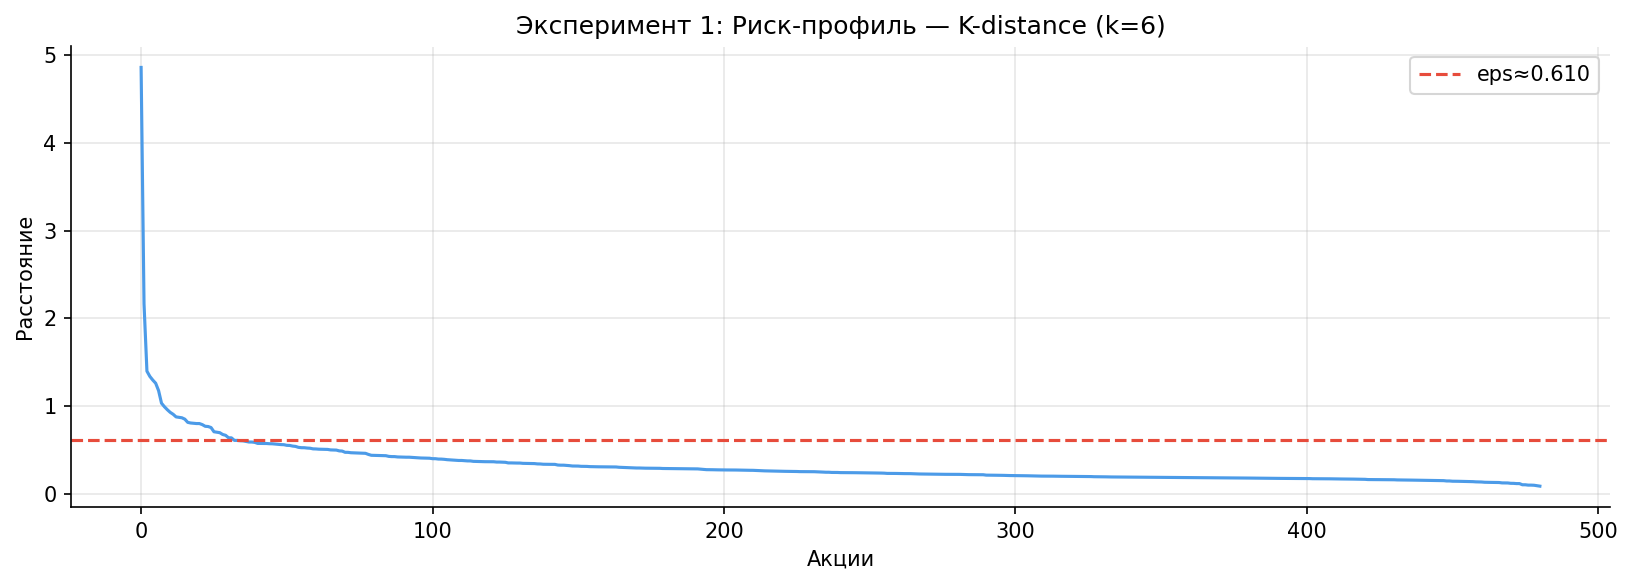

DBSCAN (eps=0.61): 1 кластеров, 15 выбросов

Акции-выбросы (экстремальный риск):
        sigma   beta  max_dd                  sector
ticker                                              
APA     0.678  1.521  -0.888                  Energy
CCL     0.698  1.874  -0.887  Consumer Discretionary
CVNA    1.115  2.359  -0.990  Consumer Discretionary
XYZ     0.615  1.902  -0.861              Financials
DG      0.323  0.520  -0.709        Consumer Staples
EQT     0.565  0.877  -0.769                  Energy
SATS    0.493  0.891  -0.783  Communication Services
MPWR    0.514  1.755  -0.460  Information Technology
MRNA    0.726  0.627  -0.924             Health Care
NCLH    0.738  1.902  -0.870  Consumer Discretionary
NEM     0.351  0.416  -0.624               Materials
RCL     0.627  1.689  -0.833  Consumer Discretionary
SMCI    0.724  1.397  -0.848  Information Technology
TSLA    0.649  1.573  -0.736  Consumer Discretionary
TTD     0.668  1.778  -0.643  Communication Services
Silhouette DBSCAN:

In [27]:
k_nbrs       = 2 * len(FEATURES)
nbrs         = NearestNeighbors(n_neighbors=k_nbrs).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dists      = np.sort(distances[:, -1])[::-1]

# Авто-локоть
x_v  = np.arange(len(k_dists))
p1, p2 = np.array([x_v[0], k_dists[0]]), np.array([x_v[-1], k_dists[-1]])
dlp    = np.abs(np.cross(p2-p1, p1-np.column_stack([x_v, k_dists])))
dlp   /= np.linalg.norm(p2-p1)
elbow_eps = float(k_dists[np.argmax(dlp)])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(k_dists, color='#4C9BE8', linewidth=1.5)
ax.axhline(elbow_eps, color='#e74c3c', linestyle='--',
           label=f'eps≈{elbow_eps:.3f}')
ax.set_title(f'{EXP_NAME} — K-distance (k={k_nbrs})')
ax.set_xlabel('Акции')
ax.set_ylabel('Расстояние')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

EPS, MIN_SAMP = round(elbow_eps, 2), 5
labels_db     = DBSCAN(eps=EPS, min_samples=MIN_SAMP).fit_predict(X_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = int((labels_db == -1).sum())
noise_tickers = X_raw.index[labels_db == -1].tolist()

print(f"DBSCAN (eps={EPS}): {n_clusters_db} кластеров, {n_noise} выбросов")
if noise_tickers:
    print("\nАкции-выбросы (экстремальный риск):")
    nd = X_raw.loc[noise_tickers].copy()
    nd['sector'] = df.loc[noise_tickers, 'sector']
    print(nd.round(3).to_string())

X_result['cluster_db'] = labels_db
valid_mask = labels_db != -1
sil_db = silhouette_score(X_scaled[valid_mask], labels_db[valid_mask]) \
    if n_clusters_db > 1 and valid_mask.sum() > n_clusters_db else np.nan
print(f"Silhouette DBSCAN: {sil_db:.3f}" if not np.isnan(sil_db)
      else "Silhouette DBSCAN: н/д")

## 9. Индекс неопределённости кластера

**Идея 3:** для каждой акции считаем насколько согласны
K-Means, Агломеративная и GMM.

- **Ядро кластера** — все три алгоритма согласны → надёжное назначение
- **Граничные акции** — алгоритмы расходятся → неопределённость

Это новый практический результат: инвестор знает
насколько надёжна классификация конкретной акции.

Индекс неопределённости (K-Means vs Aggl. vs GMM):
  Ядро (все согласны):         352 акций (73%)
  Пограничные (2/3 согласны):  128 акций (27%)
  Конфликт (все разные):       1 акций (0%)


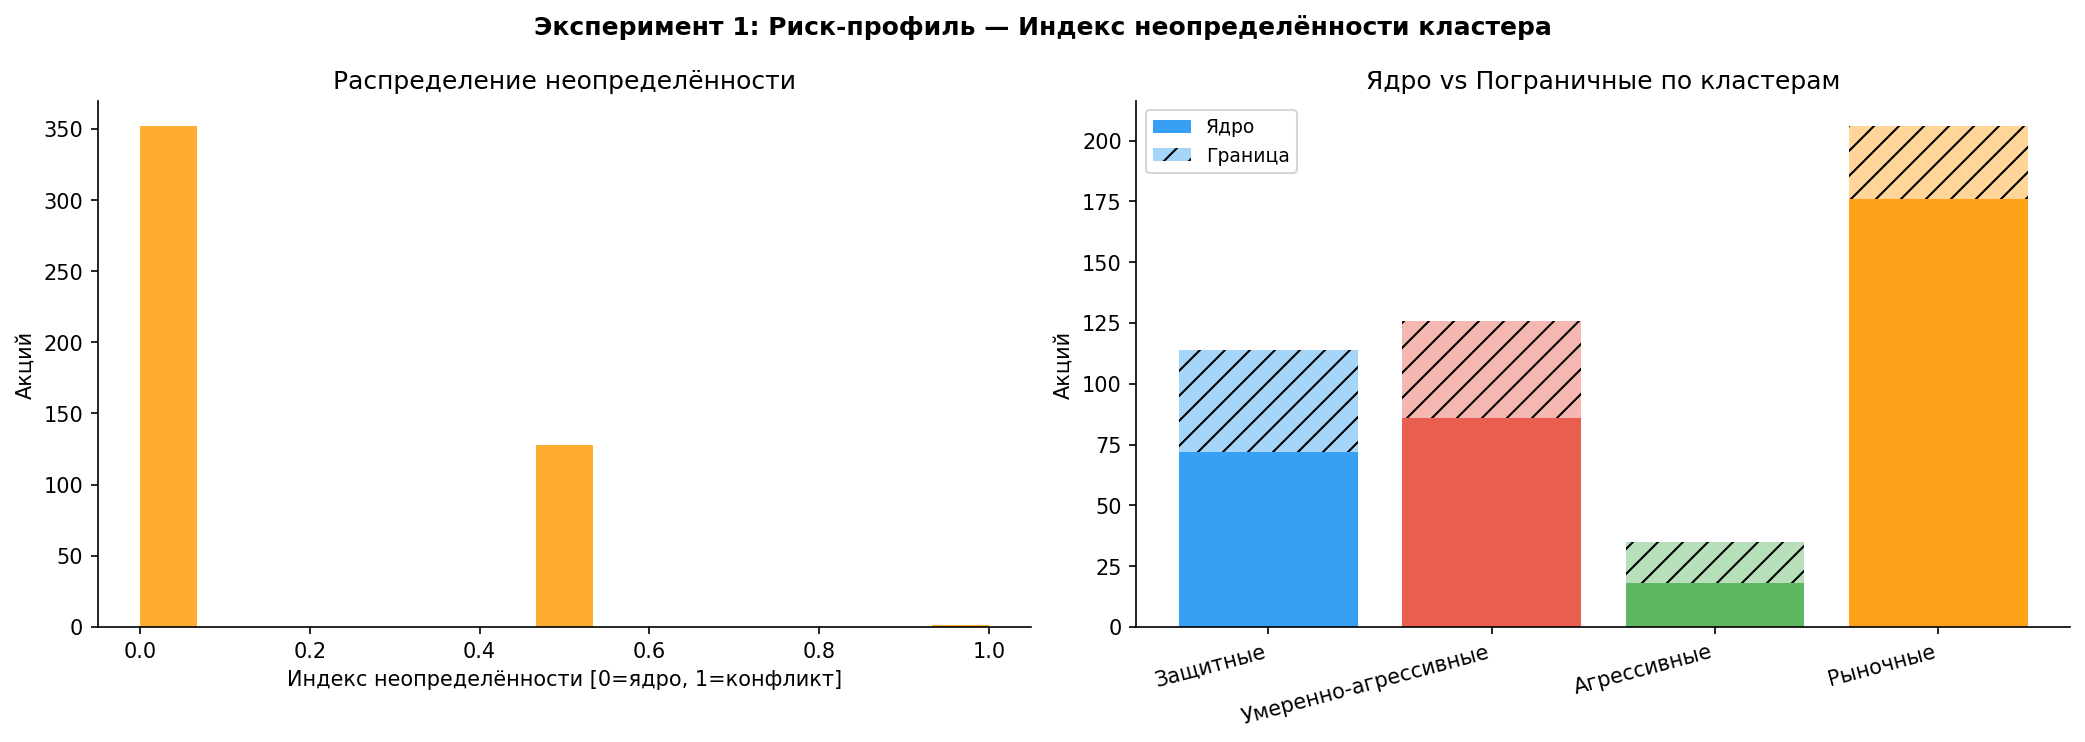


Акции с наибольшей неопределённостью (алгоритмы расходятся):
                          KM  Agg  GMM  uncertainty_idx  sigma   beta  max_dd
ticker                                                                       
DPZ                 Защитные    3    1              1.0  0.321  0.551  -0.478
ADBE    Умеренно-агрессивные    1    3              0.5  0.372  1.262  -0.600
PRU     Умеренно-агрессивные    1    3              0.5  0.365  1.304  -0.612
PFG     Умеренно-агрессивные    1    3              0.5  0.365  1.273  -0.589
PFE                 Защитные    3    3              0.5  0.264  0.549  -0.548
PEG                 Защитные    0    3              0.5  0.244  0.688  -0.408
PCAR                Защитные    0    3              0.5  0.270  0.851  -0.378
PANW                Рыночные    1    1              0.5  0.405  1.023  -0.480
ON               Агрессивные    1    1              0.5  0.548  1.778  -0.670
ORLY                Защитные    0    3              0.5  0.268  0.751  -0.420
OD

In [28]:
# Нормализуем метки (разные алгоритмы могут нумеровать по-разному)
# Используем ARI для выравнивания
def align_labels(ref_labels, labels_to_align, n_clusters):
    """Переназначает метки чтобы максимизировать совпадение с ref."""
    from scipy.optimize import linear_sum_assignment
    cost_matrix = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost_matrix[i, j] = -np.sum(
                (ref_labels == i) & (labels_to_align == j)
            )
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = dict(zip(col_ind, row_ind))
    return np.array([mapping.get(l, l) for l in labels_to_align])


labels_agg_aligned = align_labels(labels_km, labels_agg, K_FINAL)
labels_gmm_aligned = align_labels(labels_km, labels_gmm, K_FINAL)

# Индекс неопределённости = доля несогласных алгоритмов
stacked = np.column_stack([
    labels_km, labels_agg_aligned, labels_gmm_aligned
])
# Если все три согласны → 0, два из трёх согласны → 0.33
n_unique_labels = np.array([len(np.unique(row)) for row in stacked])
uncertainty_idx = (n_unique_labels - 1) / (3 - 1)  # нормировано [0,1]

X_result['uncertainty_idx'] = uncertainty_idx
n_core     = (uncertainty_idx == 0.0).sum()
n_border   = (uncertainty_idx == 0.5).sum()
n_conflict = (uncertainty_idx == 1.0).sum()

print(f"Индекс неопределённости (K-Means vs Aggl. vs GMM):")
print(f"  Ядро (все согласны):         {n_core} акций "
      f"({n_core/len(X_result)*100:.0f}%)")
print(f"  Пограничные (2/3 согласны):  {n_border} акций "
      f"({n_border/len(X_result)*100:.0f}%)")
print(f"  Конфликт (все разные):       {n_conflict} акций "
      f"({n_conflict/len(X_result)*100:.0f}%)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{EXP_NAME} — Индекс неопределённости кластера',
             fontsize=12, fontweight='bold')

axes[0].hist(uncertainty_idx, bins=15,
             color='#FF9800', alpha=0.8)
axes[0].set_xlabel('Индекс неопределённости [0=ядро, 1=конфликт]')
axes[0].set_ylabel('Акций')
axes[0].set_title('Распределение неопределённости')

# Ядро vs граница по кластерам K-Means
for c_id, (c_name, c_color) in CLUSTER_NAMES.items():
    mask    = labels_km == c_id
    core_n  = ((uncertainty_idx == 0) & mask).sum()
    bord_n  = ((uncertainty_idx > 0)  & mask).sum()
    axes[1].bar(c_name, core_n,   color=c_color, alpha=0.9,
                label='Ядро'   if c_id == 0 else '')
    axes[1].bar(c_name, bord_n, bottom=core_n,
                color=c_color, alpha=0.4,
                label='Граница' if c_id == 0 else '',
                hatch='//')

axes[1].set_title('Ядро vs Пограничные по кластерам')
axes[1].set_ylabel('Акций')
axes[1].legend(fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_uncertainty.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Самые неопределённые акции
print("\nАкции с наибольшей неопределённостью (алгоритмы расходятся):")
conflict_df = X_result[X_result['uncertainty_idx'] > 0].copy()
conflict_df['KM']  = [CLUSTER_NAMES[c][0] for c in conflict_df['cluster_km']]
conflict_df['Agg'] = labels_agg_aligned[X_result['uncertainty_idx'] > 0]
conflict_df['GMM'] = labels_gmm_aligned[X_result['uncertainty_idx'] > 0]
print(conflict_df[['KM','Agg','GMM','uncertainty_idx'] + FEATURES]
      .sort_values('uncertainty_idx', ascending=False)
      .head(15).round(3).to_string())

## 10. Анализ стабильности кластеров (Идея 1)

Разбиваем 2019–2024 на три подпериода:
- 2019–2020: бычий рынок + COVID
- 2021–2022: восстановление + инфляция  
- 2023–2024: AI-бум + ставки

Если акция всегда в одном кластере → кластер стабилен.
Если прыгает → кластер зависит от периода.

In [29]:
prices         = pd.read_parquet('data/prices.parquet')
simple_returns = pd.read_parquet('data/simple_returns.parquet')
sp500_ret      = pd.read_parquet('data/sp500_index.parquet')['sp500']

SUBPERIODS = {
    '2019–2020': ('2019-01-01', '2020-12-31'),
    '2021–2022': ('2021-01-01', '2022-12-31'),
    '2023–2024': ('2023-01-01', '2024-12-31'),
}
RISK_FREE = 0.04 / 252


def compute_risk_features(simple_ret, price, sp500, rf):
    """Быстрый расчёт риск-метрик для одного подпериода."""
    mkt = sp500.reindex(simple_ret.index).dropna()
    s_a = simple_ret.reindex(mkt.index)
    sigma = float(simple_ret.std() * np.sqrt(252))
    thr   = np.percentile(simple_ret.dropna(), 5)
    cvar  = float(simple_ret[simple_ret <= thr].mean())
    cum   = price / price.iloc[0]
    mxdd  = float((cum - cum.cummax()).div(cum.cummax()).min())
    a     = pd.concat([s_a, mkt], axis=1).dropna()
    cov   = np.cov(a.values.T)
    beta  = float(cov[0,1]/cov[1,1]) if cov[1,1]>1e-10 else np.nan
    return [sigma, beta, mxdd, cvar]


subperiod_labels = {}
tickers_full     = X_raw.index.tolist()

for period_name, (start, end) in SUBPERIODS.items():
    print(f"Подпериод {period_name}...", end=' ')
    recs = []
    for ticker in tickers_full:
        try:
            s = simple_returns[ticker].loc[start:end].dropna()
            p = prices[ticker].loc[start:end].dropna()
            sp = sp500_ret.loc[start:end]
            if len(s) < 100: continue
            feats = compute_risk_features(s, p, sp, RISK_FREE)
            if not any(np.isnan(feats)):
                recs.append({'ticker': ticker,
                             **dict(zip(FEATURES, feats))})
        except Exception:
            pass

    sub_df  = pd.DataFrame(recs).set_index('ticker')
    sub_X   = pd.DataFrame(
        RobustScaler().fit_transform(sub_df[FEATURES]),
        index=sub_df.index, columns=FEATURES
    )
    sub_km  = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
    sub_lbl = sub_km.fit_predict(sub_X)
    subperiod_labels[period_name] = pd.Series(
        sub_lbl, index=sub_df.index
    )
    print(f"{len(sub_df)} акций")

# Стабильность: насколько кластер акции менялся
common = set.intersection(*[
    set(v.index) for v in subperiod_labels.values()
]).intersection(set(tickers_full))
common = sorted(common)

stability_df = pd.DataFrame(
    {p: subperiod_labels[p].loc[common] for p in SUBPERIODS}
)

# Выравниваем метки через ARI с полным периодом
full_labels_common = pd.Series(labels_km, index=X_raw.index).loc[common]
for col in stability_df.columns:
    stability_df[col] = align_labels(
        full_labels_common.values,
        stability_df[col].values,
        K_FINAL
    )

# Количество уникальных кластеров за 3 периода = нестабильность
stability_df['n_unique'] = stability_df[
    list(SUBPERIODS.keys())
].nunique(axis=1)
stability_df['stable']   = stability_df['n_unique'] == 1
stability_df['full_km']  = full_labels_common.values
stability_df['name']     = [df.loc[t,'name']
                             if t in df.index else ''
                             for t in common]

n_stable = stability_df['stable'].sum()
pct_stable = n_stable / len(stability_df) * 100
print(f"\nСтабильность кластеров:")
print(f"  Всегда в одном кластере: {n_stable} акций ({pct_stable:.0f}%)")
print(f"  Меняли кластер:          "
      f"{len(stability_df)-n_stable} акций")

# Стабильность по кластерам
print("\nСтабильность по кластерам:")
for c in range(K_FINAL):
    mask = stability_df['full_km'] == c
    stab = stability_df.loc[mask, 'stable'].mean() * 100
    print(f"  {CLUSTER_NAMES[c][0]}: {stab:.0f}% акций стабильны")

Подпериод 2019–2020... 481 акций
Подпериод 2021–2022... 481 акций
Подпериод 2023–2024... 481 акций

Стабильность кластеров:
  Всегда в одном кластере: 124 акций (26%)
  Меняли кластер:          357 акций

Стабильность по кластерам:
  Защитные: 61% акций стабильны
  Умеренно-агрессивные: 10% акций стабильны
  Агрессивные: 9% акций стабильны
  Рыночные: 19% акций стабильны


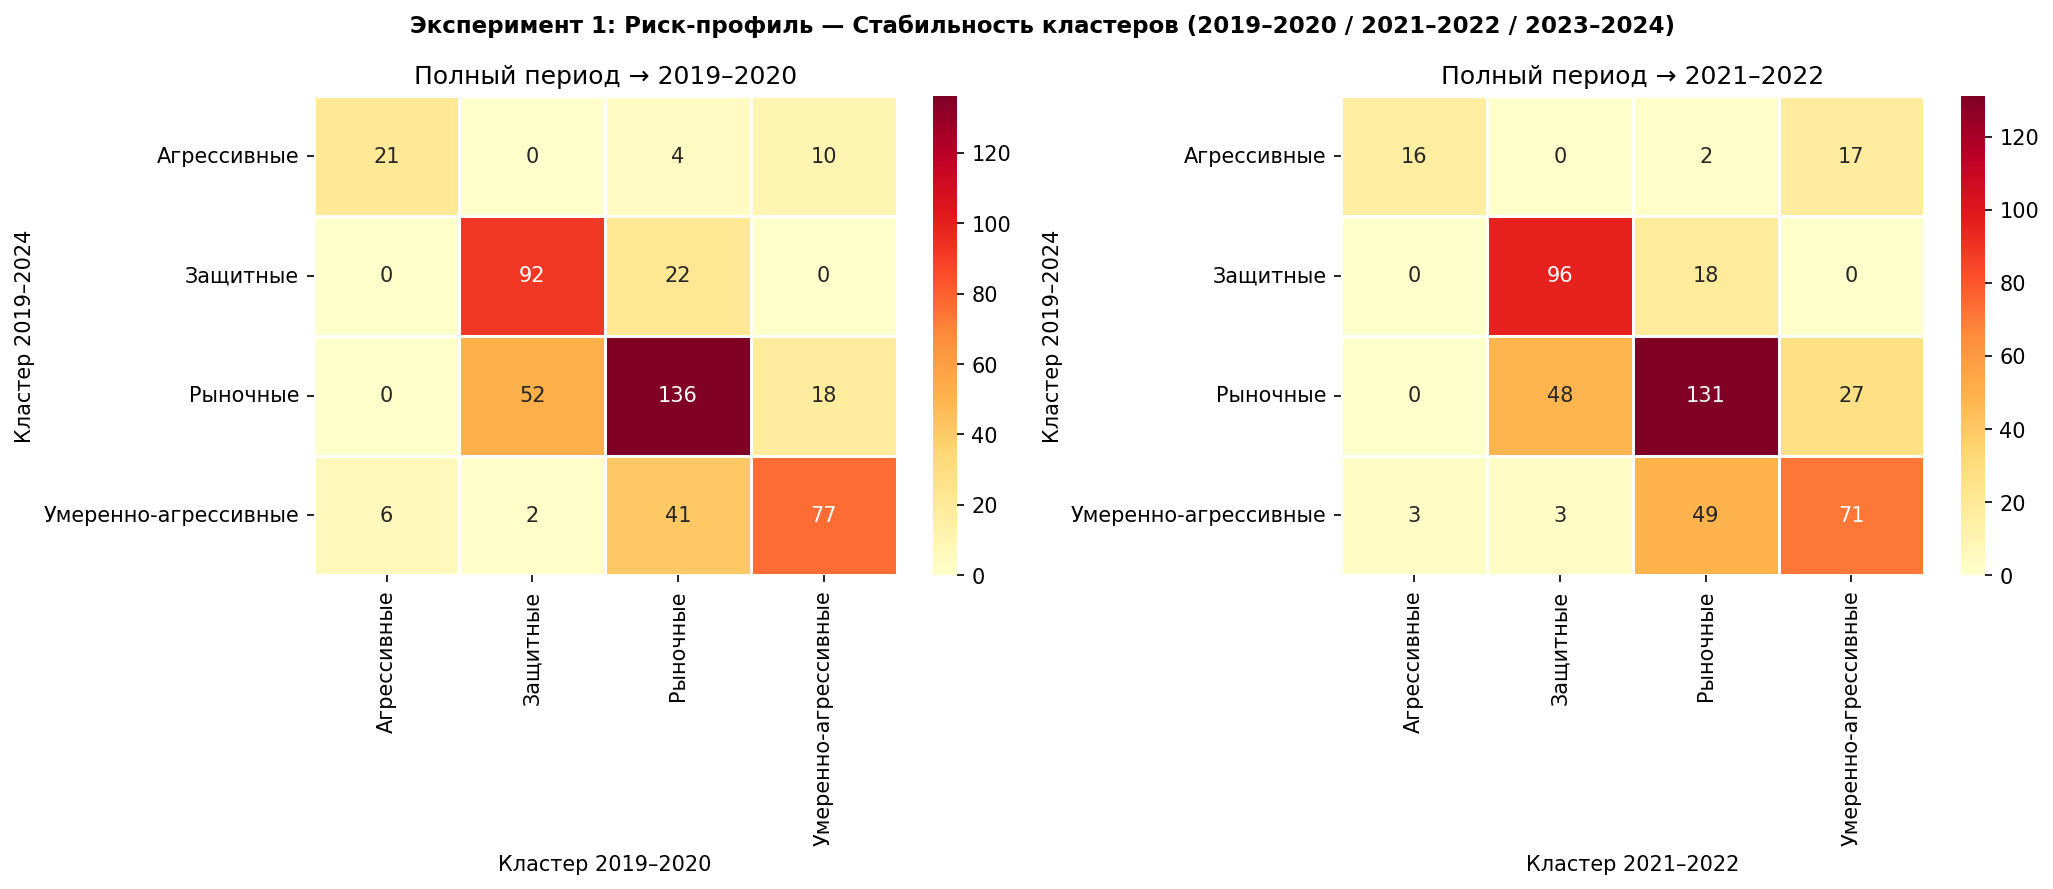


Наиболее нестабильные акции (меняли кластер в разные периоды):
                                   name  2019–2020  2021–2022  2023–2024  full_km  n_unique
ticker                                                                                     
GOOG            Alphabet Inc. (Class C)          0          1          3        3         3
GNRC                            Generac          3          2          1        2         3
FRT     Federal Realty Investment Trust          1          3          0        3         3
NFLX                            Netflix          0          2          3        1         3
CINF               Cincinnati Financial          1          3          0        3         3
TDG                     TransDigm Group          1          3          0        1         3
CHTR             Charter Communications          0          1          3        3         3
TECH                         Bio-Techne          0          1          3        3         3
GL              

In [30]:
# Визуализация стабильности
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'{EXP_NAME} — Стабильность кластеров (2019–2020 / 2021–2022 / 2023–2024)',
             fontsize=11, fontweight='bold')

# Sankey-подобная матрица: полный период vs подпериоды
periods = list(SUBPERIODS.keys())
for ax_idx, period in enumerate(periods[:2]):
    ax = axes[ax_idx]
    cross = pd.crosstab(
        stability_df['full_km'].map(
            lambda c: CLUSTER_NAMES.get(c, (str(c),))[0]
        ),
        stability_df[period].map(
            lambda c: CLUSTER_NAMES.get(c, (str(c),))[0]
        )
    )
    sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, ax=ax)
    ax.set_title(f'Полный период → {period}')
    ax.set_xlabel(f'Кластер {period}')
    ax.set_ylabel('Кластер 2019–2024')

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# Наиболее нестабильные акции
print("\nНаиболее нестабильные акции (меняли кластер в разные периоды):")
unstable = stability_df[~stability_df['stable']].copy()
cols_show = ['name'] + list(SUBPERIODS.keys()) + ['full_km','n_unique']
print(unstable[cols_show].sort_values(
    'n_unique', ascending=False
).head(15).to_string())

## 11. Силуэтный анализ

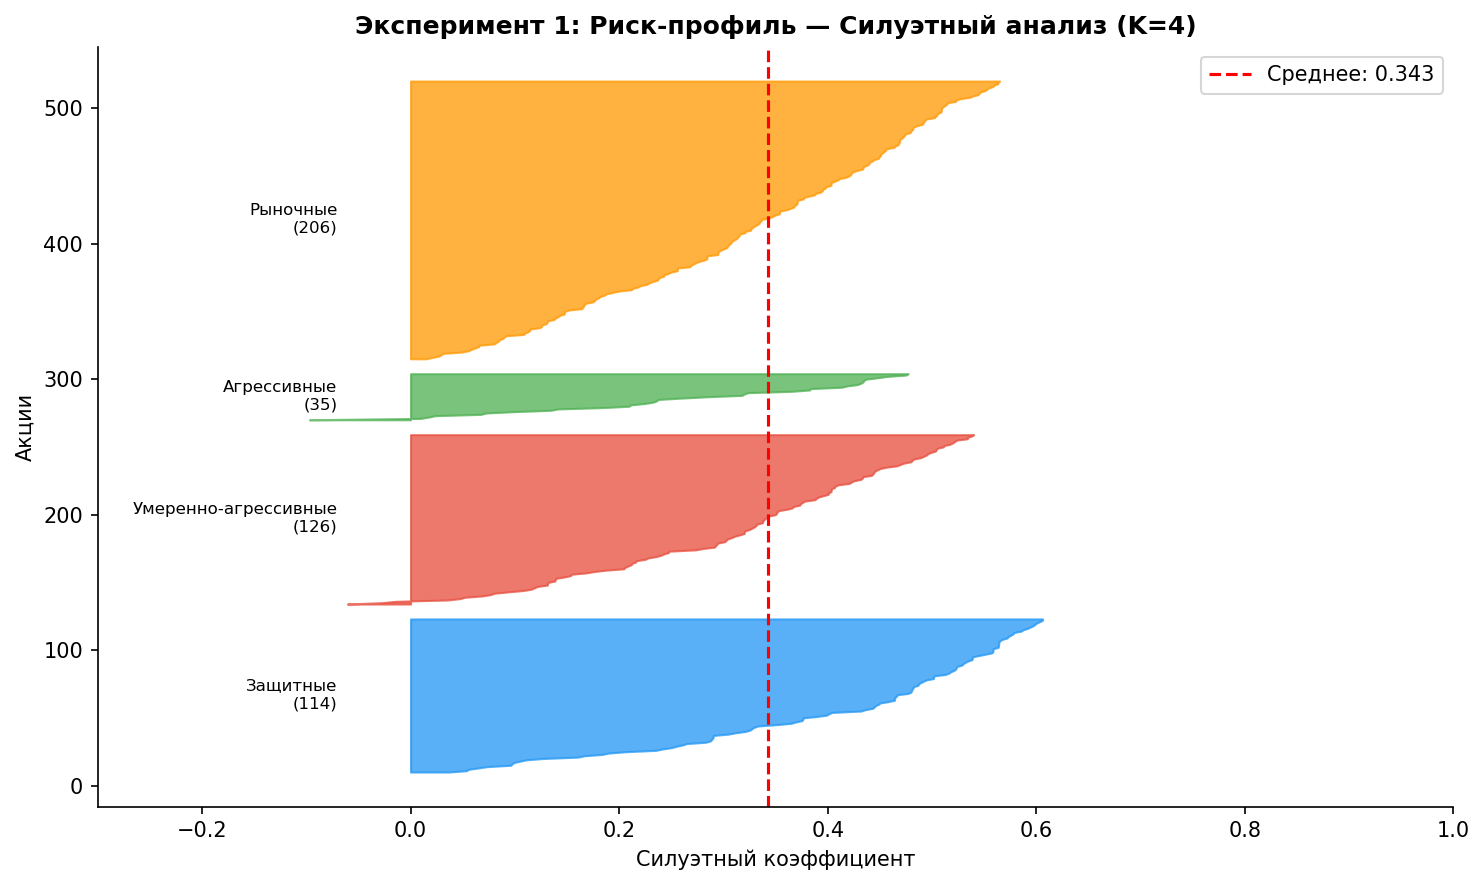

Silhouette: 0.343


In [31]:
sil_samples = silhouette_samples(X_scaled, labels_km)
sil_avg     = silhouette_score(X_scaled, labels_km)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(K_FINAL):
    cs      = np.sort(sil_samples[labels_km == i])
    y_upper = y_lower + len(cs)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cs,
                     alpha=0.75, color=CLUSTER_NAMES[i][1])
    ax.text(-0.07, y_lower+len(cs)/2,
            f'{CLUSTER_NAMES[i][0]}\n({len(cs)})',
            fontsize=8, ha='right', va='center')
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', linestyle='--',
           label=f'Среднее: {sil_avg:.3f}')
ax.set_xlabel('Силуэтный коэффициент')
ax.set_ylabel('Акции')
ax.set_title(f'{EXP_NAME} — Силуэтный анализ (K={K_FINAL})',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.3, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Silhouette: {sil_avg:.3f}")

## 12. t-SNE карта и секторальный состав

Вычисляем t-SNE...


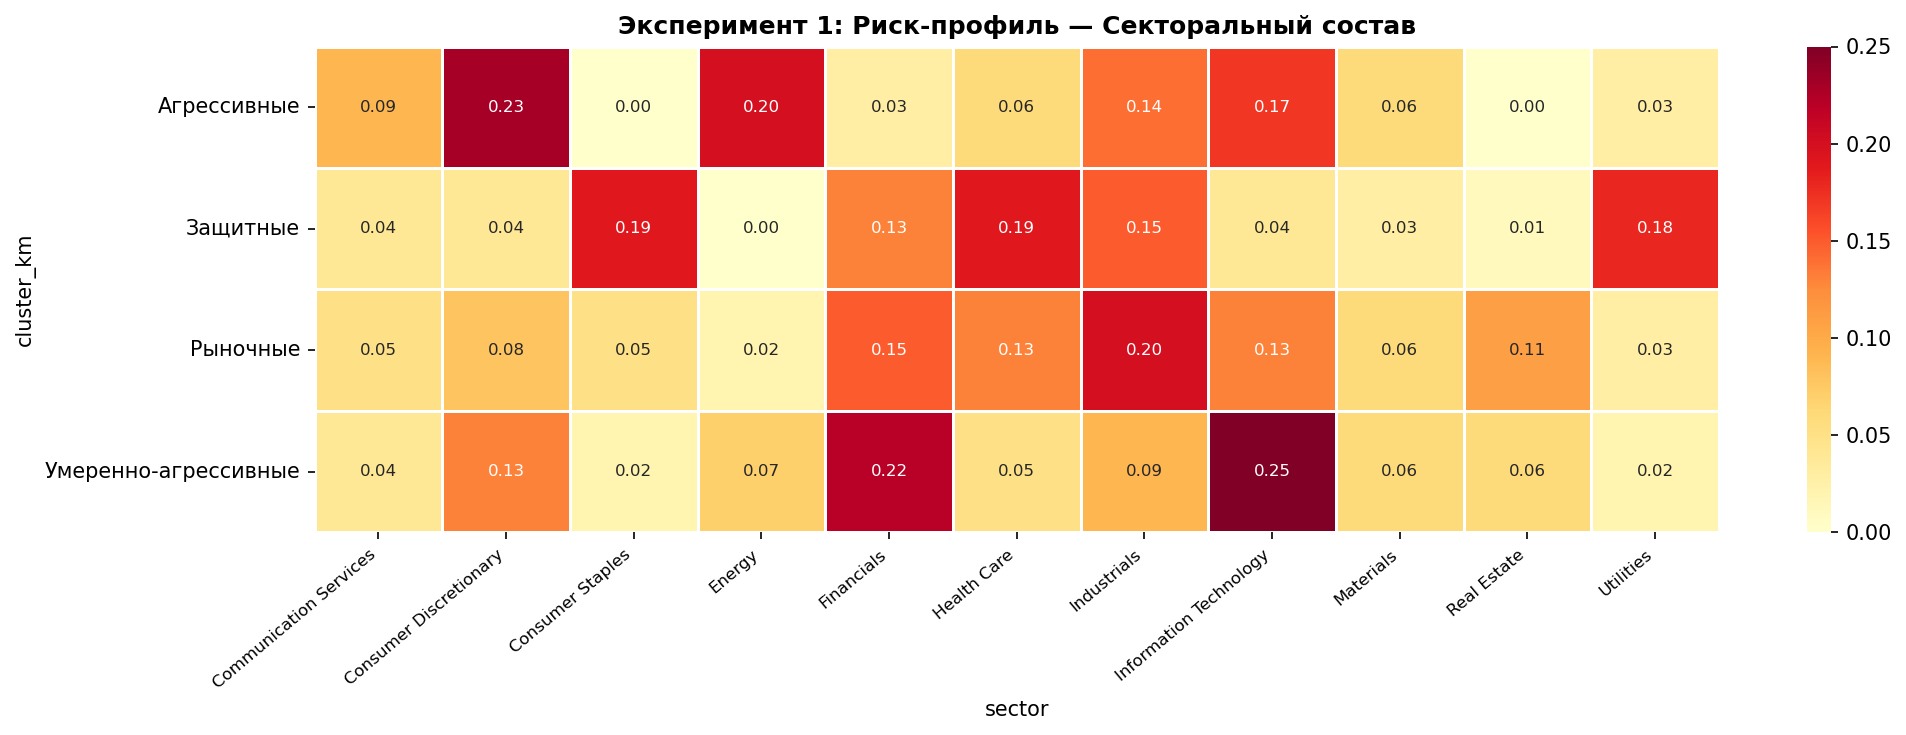

In [32]:
print("Вычисляем t-SNE...")
coords = TSNE(n_components=2, perplexity=40, random_state=42,
              learning_rate='auto', max_iter=1500).fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    'x': coords[:,0], 'y': coords[:,1],
    'ticker'       : X_raw.index,
    'cluster'      : labels_km,
    'cluster_name' : [CLUSTER_NAMES[c][0] for c in labels_km],
    'sector'       : X_result['sector'].values,
    'uncertainty'  : uncertainty_idx,
    'sigma'        : X_raw['sigma'].round(3).values,
    'beta'         : X_raw['beta'].round(3).values,
    #'cvar_95'      : X_raw['cvar_95'].round(3).values,
})

color_map = {CLUSTER_NAMES[c][0]: CLUSTER_NAMES[c][1]
             for c in CLUSTER_NAMES}
fig = px.scatter(
    tsne_df, x='x', y='y', color='cluster_name',
    color_discrete_map=color_map,
    hover_name='ticker',
    hover_data=['sector','sigma','beta','uncertainty'],
    title=f'{EXP_NAME} — t-SNE (K={K_FINAL})',
    width=900, height=620
)
fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.update_layout(plot_bgcolor='#f8f9fa')
fig.write_html(f'{SAVE_PREFIX}_tsne.html')
fig.show()

# Секторальный состав
cross = pd.crosstab(
    X_result['cluster_km'].map(
        lambda c: CLUSTER_NAMES.get(c,(str(c),))[0]
    ),
    X_result['sector'], normalize='index'
).round(2)

fig2, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cross, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title(f'{EXP_NAME} — Секторальный состав',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_sector.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Полный вывод компаний по кластерам



In [33]:
print("=" * 70)
print(f"  ПОЛНЫЙ СОСТАВ КЛАСТЕРОВ — {EXP_NAME}")
print("=" * 70)

for c_id, (c_name, c_color) in CLUSTER_NAMES.items():
    mask    = X_result['cluster_km'] == c_id
    members = X_result[mask].copy()
    members = members.sort_values('sigma')

    print(f"\n{'─'*70}")
    print(f"  КЛАСТЕР {c_id}: {c_name.upper()} ({mask.sum()} акций)")
    print(f"  σ среднее={members['sigma'].mean():.3f} | "
          f"β среднее={members['beta'].mean():.2f} | "
          f"max_dd среднее={members['max_dd'].mean():.2f} | ")
          
    print(f"{'─'*70}")

    # Таблица с метриками
    show = members[FEATURES + ['sector']].copy()
    show.index.name = 'Тикер'
    show.columns = [LABELS.get(c,c) for c in FEATURES] + ['Сектор']
    print(show.round(3).to_string())

    # Индекс неопределённости
    unc_mask = (X_result['cluster_km'] == c_id)
    core_pct = (uncertainty_idx[unc_mask.values] == 0).mean() * 100
    print(f"\n  Ядро кластера (все алгоритмы согласны): {core_pct:.0f}%")

    # Стабильность в подпериодах
    if c_id in range(K_FINAL):
        st_mask = stability_df['full_km'] == c_id
        if st_mask.sum() > 0:
            stab_pct = stability_df.loc[st_mask, 'stable'].mean()*100
            print(f"  Стабильность (одинаковый кластер во всех периодах): "
                  f"{stab_pct:.0f}%")

  ПОЛНЫЙ СОСТАВ КЛАСТЕРОВ — Эксперимент 1: Риск-профиль

──────────────────────────────────────────────────────────────────────
  КЛАСТЕР 0: ЗАЩИТНЫЕ (114 акций)
  σ среднее=0.256 | β среднее=0.67 | max_dd среднее=-0.35 | 
──────────────────────────────────────────────────────────────────────
       Волатильность (σ)  Бета (β)  Макс. просадка                  Сектор
Тикер                                                                     
JNJ                0.193     0.484          -0.274             Health Care
KO                 0.201     0.610          -0.370        Consumer Staples
CL                 0.202     0.501          -0.226        Consumer Staples
PG                 0.204     0.547          -0.238        Consumer Staples
VZ                 0.207     0.420          -0.412  Communication Services
BRK-B              0.208     0.810          -0.296              Financials
PEP                0.211     0.649          -0.288        Consumer Staples
KMB                0.212     0.

## 14. Итоговое сравнение алгоритмов

In [34]:
ari_km_agg = adjusted_rand_score(labels_km, labels_agg)
ari_km_gmm = adjusted_rand_score(labels_km, labels_gmm)
ari_agg_gmm= adjusted_rand_score(labels_agg, labels_gmm)

valid_db  = labels_db != -1
ari_km_db = adjusted_rand_score(
    labels_km[valid_db], labels_db[valid_db]
) if n_clusters_db > 1 else np.nan

rows = []
for algo, lbl, extra in [
    ('K-Means',        labels_km,  f'K={K_FINAL}'),
    ('Агломеративная', labels_agg, f'K={K_FINAL}, Ward, dendro={dendro_k}'),
    ('GMM',            labels_gmm,
     f'K={K_FINAL}, BIC={gmm.bic(X_scaled):.0f}'),
]:
    rows.append({
        'Алгоритм'   : algo,
        'Параметры'  : extra,
        'Silhouette↑': round(silhouette_score(X_scaled, lbl), 3),
        'CH↑'        : round(calinski_harabasz_score(X_scaled, lbl), 1),
        'DB↓'        : round(davies_bouldin_score(X_scaled, lbl), 3),
    })
rows.append({
    'Алгоритм'   : 'DBSCAN',
    'Параметры'  : f'eps={EPS}',
    'Silhouette↑': round(sil_db,3) if not np.isnan(sil_db) else 'н/д',
    'CH↑': '—', 'DB↓': '—'
})

print(f"{'='*65}")
print(f"  Сравнение алгоритмов — {EXP_NAME}")
print(f"{'='*65}")
print(pd.DataFrame(rows).set_index('Алгоритм').to_string())
print(f"\n  ARI (KM vs Aggl): {ari_km_agg:.3f}")
print(f"  ARI (KM vs GMM):  {ari_km_gmm:.3f}")
print(f"  ARI (Ag vs GMM):  {ari_agg_gmm:.3f}")
if not np.isnan(ari_km_db):
    print(f"  ARI (KM vs DB):   {ari_km_db:.3f}")
print(f"  DBSCAN выбросов: {n_noise} акций")
print(f"  Ядро кластеров:  {n_core} акций ({n_core/len(X_result)*100:.0f}%)")
print(f"  Стабильность:    {pct_stable:.0f}% акций не меняли кластер")
print(f"{'='*65}")

  Сравнение алгоритмов — Эксперимент 1: Риск-профиль
                          Параметры Silhouette↑    CH↑    DB↓
Алгоритм                                                     
K-Means                         K=4       0.343  441.8  0.917
Агломеративная  K=4, Ward, dendro=2       0.338  399.4  0.895
GMM                   K=4, BIC=2495       0.222  238.8  1.106
DBSCAN                     eps=0.61         н/д      —      —

  ARI (KM vs Aggl): 0.805
  ARI (KM vs GMM):  0.414
  ARI (Ag vs GMM):  0.474
  DBSCAN выбросов: 15 акций
  Ядро кластеров:  352 акций (73%)
  Стабильность:    26% акций не меняли кластер


## 15. Сохранение

In [35]:
results = pd.DataFrame({
    'cluster_exp1_km'   : labels_km,
    'cluster_exp1_agg'  : labels_agg,
    'cluster_exp1_gmm'  : labels_gmm,
    'cluster_exp1_db'   : labels_db,
    'cluster_exp1_name' : [CLUSTER_NAMES[c][0] for c in labels_km],
    'gmm_max_prob'      : max_proba,
    'uncertainty_idx'   : uncertainty_idx,
}, index=X_raw.index)
results.to_parquet('data/results_exp1.parquet')

stability_df.to_parquet('data/stability_exp1.parquet')

quality = {
    'experiment'      : 'Exp1_Risk',
    'features'        : str(FEATURES),
    'k_final'         : K_FINAL,
    'silhouette_km'   : round(silhouette_score(X_scaled, labels_km), 3),
    'silhouette_agg'  : round(silhouette_score(X_scaled, labels_agg), 3),
    'silhouette_gmm'  : round(silhouette_score(X_scaled, labels_gmm), 3),
    'silhouette_db'   : round(sil_db,3) if not np.isnan(sil_db) else None,
    'ch_km'           : round(calinski_harabasz_score(X_scaled, labels_km),1),
    'db_score_km'     : round(davies_bouldin_score(X_scaled, labels_km), 3),
    'ari_km_agg'      : round(ari_km_agg, 3),
    'ari_km_gmm'      : round(ari_km_gmm, 3),
    'ari_agg_gmm'     : round(ari_agg_gmm, 3),
    'gmm_bic'         : round(gmm.bic(X_scaled), 1),
    'dbscan_clusters' : n_clusters_db,
    'dbscan_noise'    : n_noise,
    'dendro_k'        : dendro_k,
    'core_pct'        : round(n_core/len(X_result)*100, 1),
    'stability_pct'   : round(pct_stable, 1),
}
pd.DataFrame([quality]).to_csv('data/quality_exp1.csv', index=False)

print("✓ Сохранено:")
print("  data/results_exp1.parquet")
print("  data/stability_exp1.parquet")
print("  data/quality_exp1.csv")
print(f"  Следующий шаг: notebook_04_exp2_return.ipynb")

✓ Сохранено:
  data/results_exp1.parquet
  data/stability_exp1.parquet
  data/quality_exp1.csv
  Следующий шаг: notebook_04_exp2_return.ipynb
